In [519]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
# ignore warnings

import warnings
warnings.filterwarnings('ignore')

In [520]:
# plotting parameters
plt.rc('axes', labelsize=10)
plt.rc('axes', labelweight='regular')
plt.rc('axes', titleweight='regular')
plt.rc('axes', linewidth=1)
plt.rc('xtick',labelsize=10,direction='in',top=True)
plt.rc('ytick',labelsize=10,direction='in',right=True)
plt.rcParams['xtick.major.pad']='10'
plt.rcParams['ytick.major.pad']='10'

paper_params = {'text.usetex' : True,
           'font.size' : 14,
           'font.family' : 'lmodern',
           'figure.dpi' : 200,
           }
plt.rcParams.update(paper_params)
## 3.5 x 3 inch figure size for single column in paper
## 7 x 3 inch figure size for two column in paper


In [521]:
sigma_SB = 5.670374419e-8  # Stefan-Boltzmann constant (W/m²/K⁴)
R_Earth = 6378100.0 # earth radius in meters

## read new files and compare outputs - flux at the surface vs flux at the base of the crust

In [514]:
surface_heat_flux_data_dir = '/Users/dimoff/Radiogenic_Heating/planet_models/thermal_evolution_Foley_Unterborn/test_surface_heat_flux/'
surface_heat_flux_file = 'Earth_surface_heat_fluxWm2.dat' # in the future, this will have to be more flexible with the file name, but for now, just hardcode it

In [515]:
surf_heat_flux_data = np.loadtxt(surface_heat_flux_data_dir + surface_heat_flux_file)
surf_heat_flux_time = surf_heat_flux_data[:,0]
surf_heat_flux = surf_heat_flux_data[:,1]

In [516]:
m1_earth_heat_flux_file = 'mass_sweep/Earth_heat_fluxWm2_1.00m.dat'
m1_time, m1_conv_heat_flux, m1_mag_heat_flux, m1_mag_surf_flux = np.genfromtxt(m1_earth_heat_flux_file, unpack=True)

In [517]:
for t1, t2 in zip(surf_heat_flux_time, m1_time):
    if abs(t1-t2) > 1e-6:
        print(f"Time mismatch: {t1} vs {t2}")

(-0.001, 0.35)

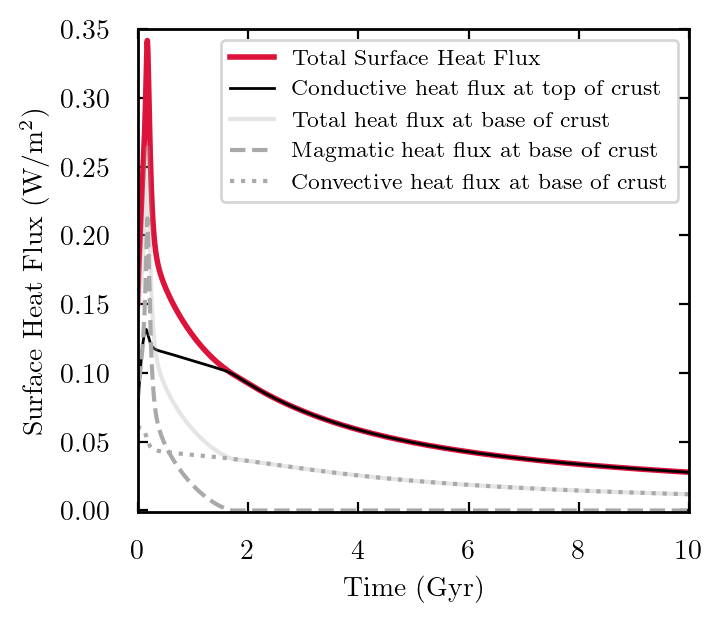

In [518]:
fig, ax = plt.subplots(1,1, figsize=(3.5, 3), dpi=200, constrained_layout=True)

ax.plot(surf_heat_flux_time, surf_heat_flux + m1_mag_heat_flux, c='crimson', ls='-', lw=2.0, alpha=1.0, label='Total Surface Heat Flux')

ax.plot(surf_heat_flux_time, surf_heat_flux, color='black', lw=1, label='Conductive heat flux at top of crust', alpha=1.0)

ax.plot(m1_time, m1_mag_heat_flux + m1_conv_heat_flux,  c='darkgrey', ls='-', lw=1.5, alpha=0.30, label='Total heat flux at base of crust')
ax.plot(m1_time, m1_mag_heat_flux,  c='darkgrey', ls='--', lw=1.5, alpha=1.0, label='Magmatic heat flux at base of crust')
ax.plot(m1_time, m1_conv_heat_flux,  c='darkgrey', ls=':', lw=1.5, alpha=1.0, label='Convective heat flux at base of crust')

#ax.scatter(4.5, 0.087, edgecolor='crimson', facecolor='white', s=30, marker='o', label='Present-day Earth Heat Flux')

ax.legend(fontsize=8, loc='upper right')
ax.set_xlabel('Time (Gyr)')
ax.set_ylabel('Surface Heat Flux (W/m$^2$)')
ax.set_xlim(0, 10)
ax.set_ylim(-0.001,0.35)

# now check surface heat fluxes for all of our sweeps

In [522]:
## and now read the files in the mass_sweep_radiogenic directory. 
radiogenic_mass_sweep_dir = '/Users/dimoff/Radiogenic_Heating/planet_models/thermal_evolution_Foley_Unterborn/mass_sweep_radiogenic/'
list_files = !ls {radiogenic_mass_sweep_dir}*heat_flux*.dat

masses = []
concentrations = []
times = []
conv_heat_fluxes = []; mag_heat_fluxes = []; surf_heat_fluxes = []

for file in list_files:
    mass = float(file.split('_')[-3].split('m')[0])
    concentration = float(file.split('_')[-2])
    masses.append(mass)
    concentrations.append(concentration)
    # read the files
    time, conv_heat_flux, mag_heat_flux, surf_heat_flux = np.genfromtxt(file, unpack=True)
    # append data to lists
    times.append(time)
    conv_heat_fluxes.append(conv_heat_flux)
    mag_heat_fluxes.append(mag_heat_flux)
    surf_heat_fluxes.append(surf_heat_flux)

#times = np.array(times); conv_heat_fluxes = np.array(conv_heat_fluxes); mag_heat_fluxes = np.array(mag_heat_fluxes); surf_heat_fluxes = np.array(surf_heat_fluxes)
masses = np.array(masses); concentrations = np.array(concentrations)
unique_masses = np.unique(masses); unique_concentrations = np.unique(concentrations)

#print(f"Unique masses: {unique_masses}")
#print(f"Unique concentrations: {unique_concentrations}")

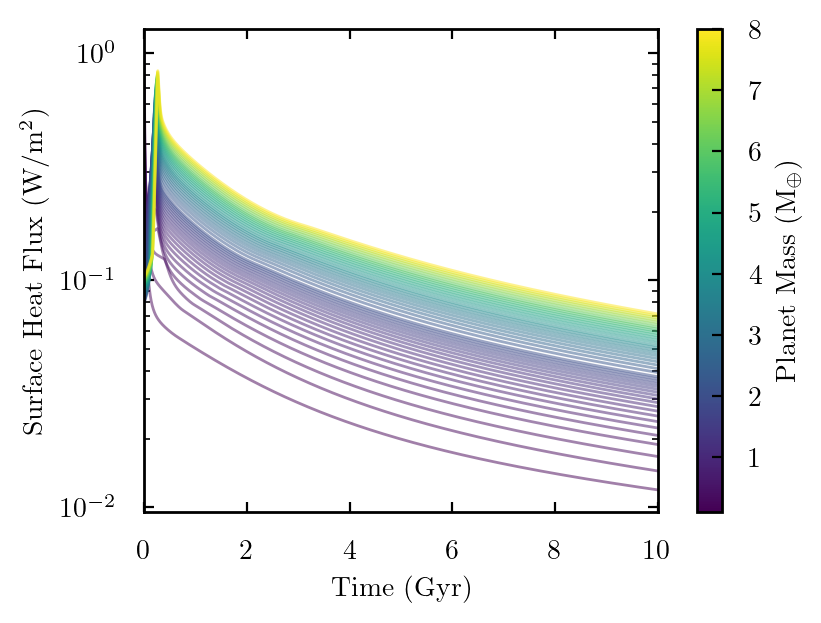

In [523]:
fig, ax = plt.subplots(1,1, figsize=(4, 3), dpi=200, constrained_layout=True)

ax.set_xlabel('Time (Gyr)')
ax.set_ylabel('Surface Heat Flux (W/m$^2$)')
ax.set_xlim(0, 10)
ax.set_yscale('log')

# plot the surface heat flux for each file, using the mass as a colorbar
for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
    #print(mass, concentration)
    if concentration != 1.0: # only plot the files with concentration not equal to 1.0
        continue
    else:
        ax.plot(time, surf_heat_flux + mag_heat_flux, alpha=0.5, lw=1.0, c=plt.cm.viridis((mass - min(masses)) / (max(masses) - min(masses))))
plt.colorbar(plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(masses), vmax=max(masses))), ax=ax, label='Planet Mass (M$_\oplus$)')

[ 0.44004008 -2.9105848 ]


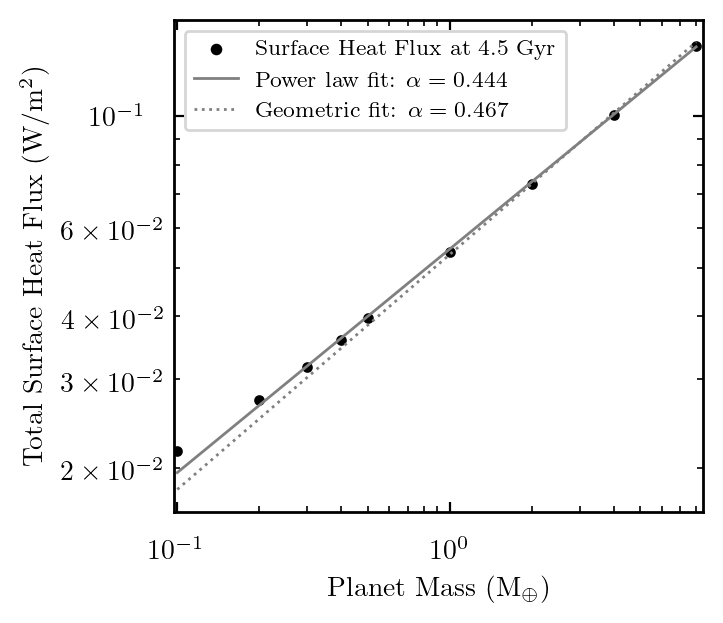

In [ ]:
# for a given time, how does the total surface heat flux vary with planet mass? Use 4.5 Gyr as reference time
ref_time = 4.5 #Gyr

fig, ax = plt.subplots(1,1, figsize=(3.5, 3), dpi=200, constrained_layout=True)
ax.set_xlabel('Planet Mass (M$_\oplus$)')
ax.set_ylabel('Total Surface Heat Flux (W/m$^2$)')
ax.set_xscale('linear')
for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
    if concentration != 1.0: # only plot the files with concentration not equal to 1.0
        continue

    if mass not in [0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 2.0, 4.0, 8.0]:
        continue
    else:
        # find the index of the time closest to ref_time
        idx = (np.abs(time - ref_time)).argmin()
        total_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
        ax.scatter(mass, total_surf_heat_flux, c='black', s=8)

# add dummy points for the legend
ax.scatter([], [], c='black', s=10, label='Surface Heat Flux at 4.5 Gyr')

# fit a power law to the data
# make a mass array with only the masses that have concentration = 1.0
masses_1_conc = np.array([mass for mass, concentration in zip(masses, concentrations) if concentration == 1.0])

total_surf_heat_fluxes = []
for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
    if concentration != 1.0: # only plot the files with concentration not equal to 1.0
        continue
    else:
        idx = (np.abs(time - ref_time)).argmin()
        total_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
        total_surf_heat_fluxes.append(total_surf_heat_flux)
total_surf_heat_fluxes = np.array(total_surf_heat_fluxes)

# fit a power law to the data
coeffs, cov = np.polyfit(np.log(masses_1_conc), np.log(total_surf_heat_fluxes), 1, cov=True)
# and plot the power law fit
mass_fit = np.linspace(min(masses_1_conc), max(masses_1_conc), 100)
total_surf_heat_flux_fit = np.exp(coeffs[1]) * mass_fit**0.444 #coeffs[0]
#total_surf_heat_flux_fit = np.exp(coeffs[1]) * mass_fit**coeffs[0]
ax.plot(mass_fit, total_surf_heat_flux_fit, c='grey', ls='-', lw=1, label=fr'Power law fit: $\alpha = {0.444}$')

# what is the uncertainty on the power law fit? Use the covariance matrix from np.polyfit
#print(f"Power law fit: y = {np.exp(coeffs[1]):.3f} * x^{coeffs[0]:.3f}")
#print(f"Uncertainty on the fit: slope = {np.sqrt(cov[0,0]):.3f}, intercept = {np.sqrt(cov[1,1]):.3f}")

# power law with a slope of 7/15 or 0.467, which is the expected scaling from Foley & Unterborn 2018
slope_expected_2 = 7/15
# adjust from the intercept slightly to fit the top half of the data
total_surf_heat_flux_fit_expected_2 = np.exp(coeffs[1]-0.025) * mass_fit**slope_expected_2
ax.plot(mass_fit, total_surf_heat_flux_fit_expected_2, c='grey', ls=':', lw=1, label=fr'Geometric fit: $\alpha = {slope_expected_2:.3f}$')

ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(0.097, max(masses_1_conc)+0.5)
ax.set_xscale('log')
ax.set_yscale('log')

In [485]:
# what is the heat flux for a 1 Earth-mass model at 4.5 Gyr?
ref_mass = 1.0 # Earth masses
ref_time = 4.5 # Gyr

for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
    if mass == ref_mass and concentration == 1.0:
        idx = (np.abs(time - ref_time)).argmin()
        total_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
        print(f'Total surface heat flux for a 1 Earth-mass planet at 4.5 Gyr: {total_surf_heat_flux} W/m^2')

Total surface heat flux for a 1 Earth-mass planet at 4.5 Gyr: 0.05364736 W/m^2


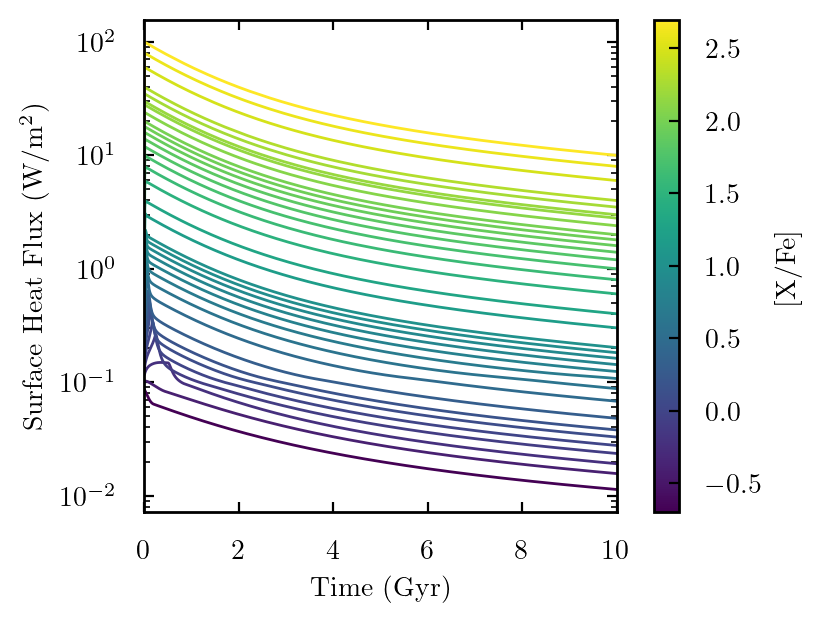

In [486]:
fig, ax = plt.subplots(1,1, figsize=(4, 3), dpi=200, constrained_layout=True)

ax.set_xlabel('Time (Gyr)')
ax.set_ylabel('Surface Heat Flux (W/m$^2$)')
ax.set_xlim(0, 10)
ax.set_yscale('log')

# remove indices where concentration = 0.0, since these are not physical
plot_params = [(mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux) for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes) if concentration != 0.0]
concentrations_in_plot_params = np.log10([concentration for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux in plot_params])

# plot the surface heat flux for each file, using the mass as a colorbar
for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux in plot_params:
    #print(concentration)
    if mass != 1.0: # only plot the files with mass equal to 1.0
        continue
    ax.plot(time, surf_heat_flux + mag_heat_flux, alpha=1.0, lw=1.0, c=plt.cm.viridis((np.log10(concentration) - min((concentrations_in_plot_params))) / (max((concentrations_in_plot_params)) - min((concentrations_in_plot_params)))))
    
plt.colorbar(plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(concentrations_in_plot_params), vmax=max(concentrations_in_plot_params))), ax=ax, label='[X/Fe]')

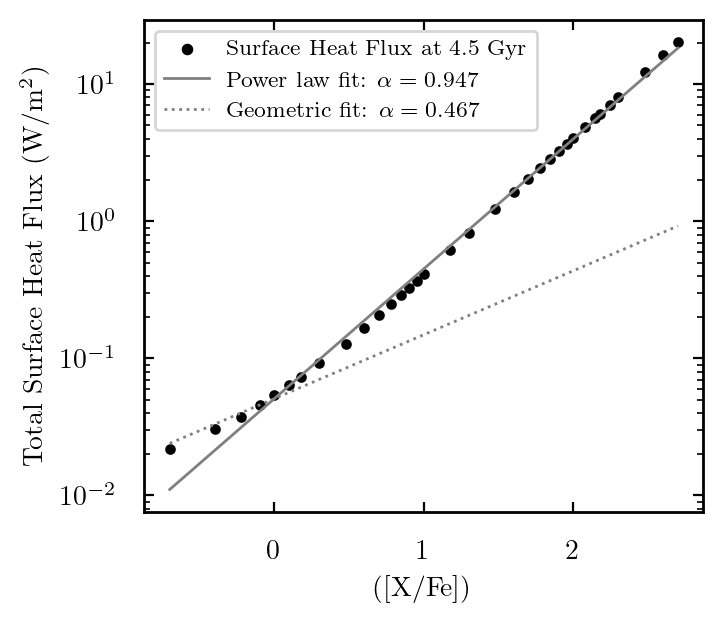

In [ ]:
# for a given time, how does the total surface heat flux vary with concentration? Use 4.5 Gyr as reference time
ref_time = 4.5 #Gyr

fig, ax = plt.subplots(1,1, figsize=(3.5, 3), dpi=200, constrained_layout=True)
ax.set_xlabel('([X/Fe])')
ax.set_ylabel('Total Surface Heat Flux (W/m$^2$)')
ax.set_xscale('linear')

total_surf_heat_fluxes = []
conc_1_mass = []
for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
    if mass != 1.0: # only plot the files with concentration not equal to 1.0
        continue
    if concentration == 0.0:
        continue
    else:
        # find the index of the time closest to ref_time
        idx = (np.abs(time - ref_time)).argmin()
        total_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
        total_surf_heat_fluxes.append(total_surf_heat_flux)
        conc_1_mass.append(concentration)
        ax.scatter(np.log10(concentration), total_surf_heat_flux, c='black', s=8)

total_surf_heat_fluxes = np.array(total_surf_heat_fluxes)
conc_1_mass = np.array(conc_1_mass)
#print(conc_1_mass)

# add dummy points for the legend
ax.scatter([], [], c='black', s=10, label=f'Surface Heat Flux at {ref_time} Gyr')

# fit a power law to the data
coeffs, cov = np.polyfit(np.log10(conc_1_mass[1:]), np.log10(total_surf_heat_fluxes[1:]), 1, cov=True)
# and plot the power law fit
conc_fit = np.linspace(min(conc_1_mass), max(conc_1_mass), 100)
total_surf_heat_flux_fit = 10**(coeffs[1]) * conc_fit**coeffs[0]
ax.plot(np.log10(conc_fit), total_surf_heat_flux_fit, c='grey', ls='-', lw=1, label=fr'Power law fit: $\alpha = {coeffs[0]:.3f}$')
#ax.legend(fontsize=8, loc='upper left')

# what is the uncertainty on the power law fit? Use the covariance matrix from np.polyfit
#print(f"Power law fit: y = {10**(coeffs[1]):.3f} * x^{coeffs[0]:.3f}")
#print(f"Uncertainty on the fit: slope = {np.sqrt(cov[0,0]):.3f}, intercept = {np.sqrt(cov[1,1]):.3f}")

# power law with a slope of 7/15 or 0.4667, which is the assumed scaling?
slope_expected_2 = 7/15
total_surf_heat_flux_fit_expected_2 = 10**(coeffs[1]) * conc_fit**slope_expected_2
ax.plot(np.log10(conc_fit), total_surf_heat_flux_fit_expected_2, c='grey', ls=':', lw=1, label=fr'Geometric fit: $\alpha = {slope_expected_2:.3f}$')


# break the data into two parts and try to fit power laws to both halves ?
#conc_1_mass_l1 = conc_1_mass < 0.999
#conc_1_mass_g1 = conc_1_mass > 0.999
#
#coeffs_l1, conv_l1 = np.polyfit(np.log10(conc_1_mass[conc_1_mass_l1][1:]), np.log10(total_surf_heat_fluxes[conc_1_mass_l1][1:]), 1, cov=True)
#conc_l1_fit = np.linspace(min(conc_1_mass[conc_1_mass_l1]), max(conc_1_mass[conc_1_mass_l1]), 100)
#l1_surf_heat_flux_fit = 10**(coeffs_l1[1]) * conc_l1_fit**coeffs_l1[0]
#ax.plot(np.log10(conc_l1_fit), l1_surf_heat_flux_fit, c='lime')
#
#coeffs_g1, conv_g1 = np.polyfit(np.log10(conc_1_mass[conc_1_mass_g1][1:]), np.log10(total_surf_heat_fluxes[conc_1_mass_g1][1:]), 1, cov=True)
#conc_g1_fit = np.linspace(min(conc_1_mass[conc_1_mass_l1]), max(conc_1_mass[conc_1_mass_g1]), 100)
#g1_surf_heat_flux_fit = 10**(coeffs_g1[1]) * conc_g1_fit**coeffs_g1[0]
#ax.plot(np.log10(conc_g1_fit), g1_surf_heat_flux_fit, c='lime')

ax.legend(fontsize=8, loc='upper left')
#ax.set_xlim(0.097, max(conc_1_mass)+0.5)
#ax.set_xscale('log')
ax.set_yscale('log')

[2.00e-01 4.00e-01 6.00e-01 8.00e-01 1.00e+00 1.25e+00 1.50e+00 1.00e+01
 1.00e+02 1.20e+02 1.40e+02 1.50e+01 1.50e+02 1.75e+02 2.00e+00 2.00e+01
 2.00e+02 3.00e+00 3.00e+01 3.00e+02 4.00e+00 4.00e+01 4.00e+02 5.00e+00
 5.00e+01 5.00e+02 6.00e+00 6.00e+01 7.00e+00 7.00e+01 8.00e+00 8.00e+01
 9.00e+00 9.00e+01]
Power law fit: y = 0.155 * x^1.036
Uncertainty on the fit: slope = 0.013, intercept = 0.019


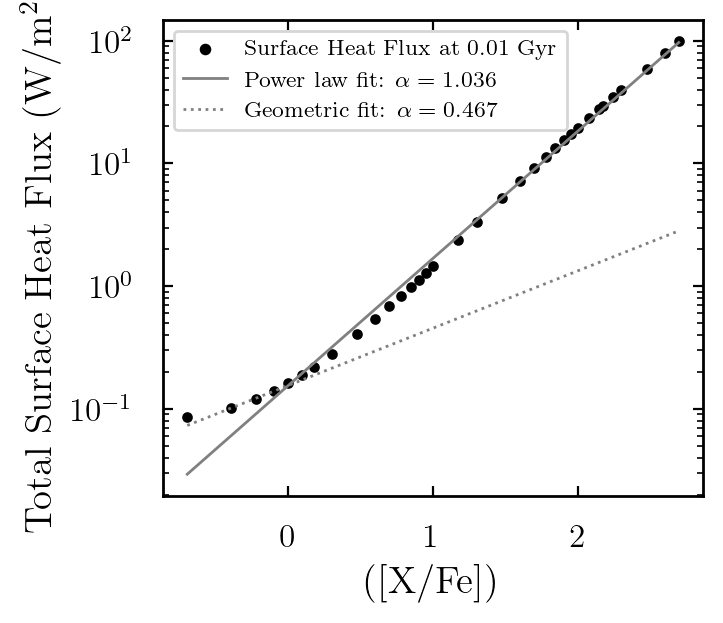

In [467]:
# for a given time, how does the total surface heat flux vary with concentration? Use 4.5 Gyr as reference time
ref_time = 0.01 #Gyr

fig, ax = plt.subplots(1,1, figsize=(3.5, 3), dpi=200, constrained_layout=True)
ax.set_xlabel('([X/Fe])')
ax.set_ylabel('Total Surface Heat Flux (W/m$^2$)')
ax.set_xscale('linear')

total_surf_heat_fluxes = []
conc_1_mass = []
for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
    if mass != 1.0: # only plot the files with concentration not equal to 1.0
        continue
    if concentration == 0.0:
        continue
    else:
        # find the index of the time closest to ref_time
        idx = (np.abs(time - ref_time)).argmin()
        total_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
        total_surf_heat_fluxes.append(total_surf_heat_flux)
        conc_1_mass.append(concentration)
        ax.scatter(np.log10(concentration), total_surf_heat_flux, c='black', s=8)

total_surf_heat_fluxes = np.array(total_surf_heat_fluxes)
conc_1_mass = np.array(conc_1_mass)

print(conc_1_mass)

# add dummy points for the legend
ax.scatter([], [], c='black', s=10, label=f'Surface Heat Flux at {ref_time} Gyr')

# fit a power law to the data
coeffs, cov = np.polyfit(np.log10(conc_1_mass[1:]), np.log10(total_surf_heat_fluxes[1:]), 1, cov=True)
# and plot the power law fit
conc_fit = np.linspace(min(conc_1_mass), max(conc_1_mass), 100)
total_surf_heat_flux_fit = 10**(coeffs[1]) * conc_fit**coeffs[0]
ax.plot(np.log10(conc_fit), total_surf_heat_flux_fit, c='grey', ls='-', lw=1, label=fr'Power law fit: $\alpha = {coeffs[0]:.3f}$')
#ax.legend(fontsize=8, loc='upper left')

# what is the uncertainty on the power law fit? Use the covariance matrix from np.polyfit
print(f"Power law fit: y = {10**(coeffs[1]):.3f} * x^{coeffs[0]:.3f}")
print(f"Uncertainty on the fit: slope = {np.sqrt(cov[0,0]):.3f}, intercept = {np.sqrt(cov[1,1]):.3f}")

# power law with a slope of 7/15 or 0.4667, which is the assumed scaling?
slope_expected_2 = 7/15
total_surf_heat_flux_fit_expected_2 = 10**(coeffs[1]) * conc_fit**slope_expected_2
ax.plot(np.log10(conc_fit), total_surf_heat_flux_fit_expected_2, c='grey', ls=':', lw=1, label=fr'Geometric fit: $\alpha = {slope_expected_2:.3f}$')

ax.legend(fontsize=8, loc='upper left')

#ax.set_xlim(0.097, max(conc_1_mass)+0.5)

#ax.set_xscale('log')
ax.set_yscale('log')

[2.00e-01 4.00e-01 6.00e-01 8.00e-01 1.00e+00 1.25e+00 1.50e+00 1.00e+01
 1.00e+02 1.20e+02 1.40e+02 1.50e+01 1.50e+02 1.75e+02 2.00e+00 2.00e+01
 2.00e+02 3.00e+00 3.00e+01 3.00e+02 4.00e+00 4.00e+01 4.00e+02 5.00e+00
 5.00e+01 5.00e+02 6.00e+00 6.00e+01 7.00e+00 7.00e+01 8.00e+00 8.00e+01
 9.00e+00 9.00e+01]
Power law fit: y = 0.030 * x^0.939
Uncertainty on the fit: slope = 0.009, intercept = 0.013


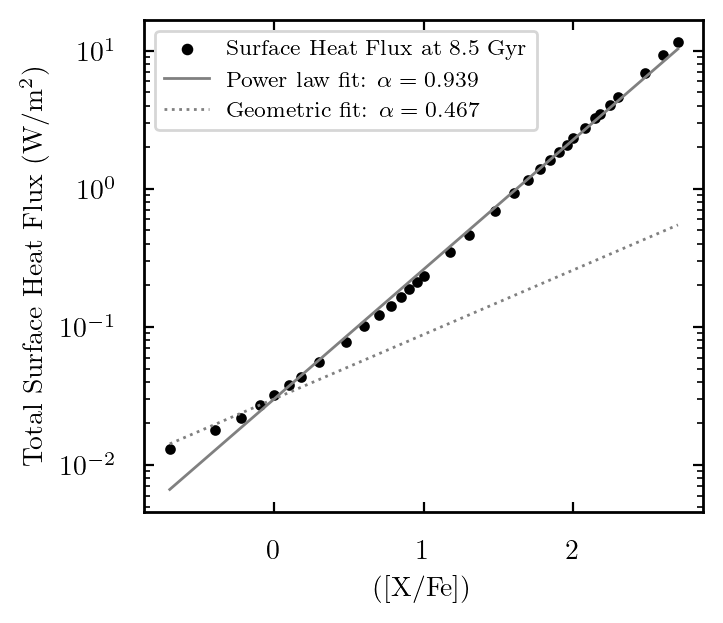

In [ ]:
# for a given time, how does the total surface heat flux vary with concentration? Use 4.5 Gyr as reference time
ref_time = 8.5 #Gyr

fig, ax = plt.subplots(1,1, figsize=(3.5, 3), dpi=200, constrained_layout=True)
ax.set_xlabel('[X/Fe]')
ax.set_ylabel('Total Surface Heat Flux (W/m$^2$)')
ax.set_xscale('linear')

total_surf_heat_fluxes = []
conc_1_mass = []
for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
    if mass != 1.0: # only plot the files with concentration equal to 1.0
        continue
    if concentration == 0.0:
        continue
    else:
        # find the index of the time closest to ref_time
        idx = (np.abs(time - ref_time)).argmin()
        total_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
        total_surf_heat_fluxes.append(total_surf_heat_flux)
        conc_1_mass.append(concentration)
        ax.scatter(np.log10(concentration), total_surf_heat_flux, c='black', s=8)

total_surf_heat_fluxes = np.array(total_surf_heat_fluxes)
conc_1_mass = np.array(conc_1_mass)

print(conc_1_mass)

# add dummy points for the legend
ax.scatter([], [], c='black', s=10, label=f'Surface Heat Flux at {ref_time} Gyr')

# fit a power law to the data
coeffs, cov = np.polyfit(np.log10(conc_1_mass[1:]), np.log10(total_surf_heat_fluxes[1:]), 1, cov=True)
# and plot the power law fit
conc_fit = np.linspace(min(conc_1_mass), max(conc_1_mass), 100)
total_surf_heat_flux_fit = 10**(coeffs[1]) * conc_fit**coeffs[0]
ax.plot(np.log10(conc_fit), total_surf_heat_flux_fit, c='grey', ls='-', lw=1, label=fr'Power law fit: $\alpha = {coeffs[0]:.3f}$')
#ax.legend(fontsize=8, loc='upper left')

# what is the uncertainty on the power law fit? Use the covariance matrix from np.polyfit
print(f"Power law fit: y = {10**(coeffs[1]):.3f} * x^{coeffs[0]:.3f}")
print(f"Uncertainty on the fit: slope = {np.sqrt(cov[0,0]):.3f}, intercept = {np.sqrt(cov[1,1]):.3f}")

# power law with a slope of 7/15 or 0.4667, which is the assumed scaling?
slope_expected_2 = 7/15
total_surf_heat_flux_fit_expected_2 = 10**(coeffs[1]) * conc_fit**slope_expected_2
ax.plot(np.log10(conc_fit), total_surf_heat_flux_fit_expected_2, c='grey', ls=':', lw=1, label=fr'Geometric fit: $\alpha = {slope_expected_2:.3f}$')

ax.legend(fontsize=8, loc='upper left')

#ax.set_xlim(0.097, max(conc_1_mass)+0.5)

#ax.set_xscale('log')
ax.set_yscale('log')

In [19]:
# in the 5 earth mass +1 dex case, what is the max and mean surface heat flux? 

file = '/Users/dimoff/Radiogenic_Heating/planet_models/thermal_evolution_Foley_Unterborn/mass_sweep_radiogenic/Earth_heat_fluxWm2_5.00m_10.00_enhanced.dat'
times, conv_heat_flux, mag_heat_flux, surf_heat_flux = np.loadtxt(file, usecols=(0,1,2,3), unpack=True)
print(np.max(surf_heat_flux + mag_heat_flux), np.mean(surf_heat_flux + mag_heat_flux))


4.170692900000001 1.5743006806816648


# how can we combine the surface heat fluxes with the stellar heat flux?

In [324]:
# read stellar_fluxes_with_distance_G2V for orbial distances and stellar heat fluxes
G2V_orbital_distances, G2V_stellar_fluxes = np.genfromtxt('stellar_fluxes_with_distance_G2V.txt', unpack=True)
K5V_orbital_distances, K5V_stellar_fluxes = np.genfromtxt('stellar_fluxes_with_distance_K5V.txt', unpack=True)
M5V_orbital_distances, M5V_stellar_fluxes = np.genfromtxt('stellar_fluxes_with_distance_M5V.txt', unpack=True)

# we can interpolate these stellar fluxes and distances for a smoother curve so we can look at distances between the data points
distances = np.linspace(0.01, 10, 10000)

from scipy.interpolate import interp1d
# we will try a log-log interpolation .
G2V_stellar_fluxes_log_interp = interp1d(np.log10(G2V_orbital_distances), np.log10(G2V_stellar_fluxes), kind='linear')
K5V_stellar_fluxes_log_interp = interp1d(np.log10(K5V_orbital_distances), np.log10(K5V_stellar_fluxes), kind='linear')
M5V_stellar_fluxes_log_interp = interp1d(np.log10(M5V_orbital_distances), np.log10(M5V_stellar_fluxes), kind='linear')

G2V_stellar_fluxes_log_interp_values = 10**G2V_stellar_fluxes_log_interp(np.log10(distances))
K5V_stellar_fluxes_log_interp_values = 10**K5V_stellar_fluxes_log_interp(np.log10(distances))
M5V_stellar_fluxes_log_interp_values = 10**M5V_stellar_fluxes_log_interp(np.log10(distances))

In [325]:
Earth_heat_flux_from_Sun = G2V_stellar_fluxes[np.where(np.isclose(G2V_orbital_distances, 1, atol=0.01, rtol=0.01))[0][0]] / 4

# compute the equlibrium temperature for each stellar type at each orbital distance, 
# assuming a Bond albedo of 0.3 and emissivity of 1.0
bond_albedo = 0.3
emissivity = 1.0

test_Earth_T_eq = ((Earth_heat_flux_from_Sun * (1 - bond_albedo))/ (sigma_SB))**0.25
## why does the factor of 4 disappear? 
# Because the stellar flux is already divided by 4 to account for the fact 
# that the planet is a sphere and only receives flux on one side, while radiating from the entire surface area.
# GOOD!
print(f"Earth heat flux from Sun: {Earth_heat_flux_from_Sun} W/m^2")
print(f"Earth equilibrium temperature: {test_Earth_T_eq} K")

Earth heat flux from Sun: 341.0960512114111 W/m^2
Earth equilibrium temperature: 254.73624856322513 K


In [308]:
# make a function to covert a heat flux into an effective temperature
def heat_flux_to_T_eff(heat_flux, bond_albedo=0.3, emissivity=1.0):
    return ((heat_flux * (1 - bond_albedo))/ (emissivity * sigma_SB))**0.25

In [313]:
heat_flux_to_T_eff(1361/4)

254.5781401165717

array([ 0.10990999,  0.11090909,  0.11190819, ...,  9.9980018 ,
        9.9990009 , 10.        ], shape=(9900,))

In [107]:
# compute the equilibrium temperature for each stellar type at each orbital distance
G2V_T_eq = ((G2V_stellar_fluxes_log_interp_values * (1 - bond_albedo))/ (sigma_SB))**0.25
K5V_T_eq = ((K5V_stellar_fluxes_log_interp_values * (1 - bond_albedo))/ (sigma_SB))**0.25
M5V_T_eq = ((M5V_stellar_fluxes_log_interp_values * (1 - bond_albedo))/ (sigma_SB))**0.25

In [ ]:
#  Here is a table of the expected surface heat fluxes for different orbital distances at 4.5 Gyr 
# for a G2V like star and an earth-like planet with 1 Earth mass and 1x radiogenic heating [X/Fe] = 0.0 dex.
#  We need to update the surface heat flux values since we have updated the models to include the
# magmatic heat flux at the surface. 
# 
# The values below are old.

# For the ‘earth’ distance: 
# Distance   stellar heat (W/m²)   [X/Fe]   Surface Heat Flux (W/m²)   Total Heat Flux (W/m²)
#	1		    340	0 dex (1x)	    0.01	340 (~1361, Solar Constant / 4)
#	1		    340	1.00		    0.27	340
#	1		    339	1.50		    0.98	340
#	1.01		336	2.00		    3.48	340
#	1.02		334	2.2 (Roeder)	5.78	340
#	1.03		328	2.50		    12	    340
#	1.08		296	3.00		    44	    340
#	1.11		283	3.10		    57	    340
#	1.16		257	3.25		    83	    340
#	1.19		245	3.30		    95	    340
#	1.21		236	3.34		    104	    340
#	1.38		183	3.50		    157	    340
#	INF?		0	3.80		    340	    340


In [ ]:
# at what distance is the stellar heat flux equal to 485 (121.5 * 4) W/m2? (outer edge of the HZ)
G2V_distance_for_120_W_m2 = distances[np.argmin(np.abs(G2V_stellar_fluxes_log_interp_values - 485))]
K5V_distance_for_120_W_m2 = distances[np.argmin(np.abs(K5V_stellar_fluxes_log_interp_values - 485))]
M5V_distance_for_120_W_m2 = distances[np.argmin(np.abs(M5V_stellar_fluxes_log_interp_values - 485))]

print(f"G2V distance for 120 W/m²: {G2V_distance_for_120_W_m2} AU")
print(f"K5V distance for 120 W/m²: {K5V_distance_for_120_W_m2} AU")
print(f"M5V distance for 120 W/m²: {M5V_distance_for_120_W_m2} AU")

G2V distance for 120 W/m²: 1.6944824482448244 AU
K5V distance for 120 W/m²: 0.6943834383438343 AU
M5V distance for 120 W/m²: 0.09192619261926192 AU


Distance: 1.009099909990999 AU
Distance: 3.007299729972997 AU
Distance: 5.005499549954995 AU
Distance: 7.003699369936993 AU
Distance: 9.00189918991899 AU


Text(2.3, 30, 'M')

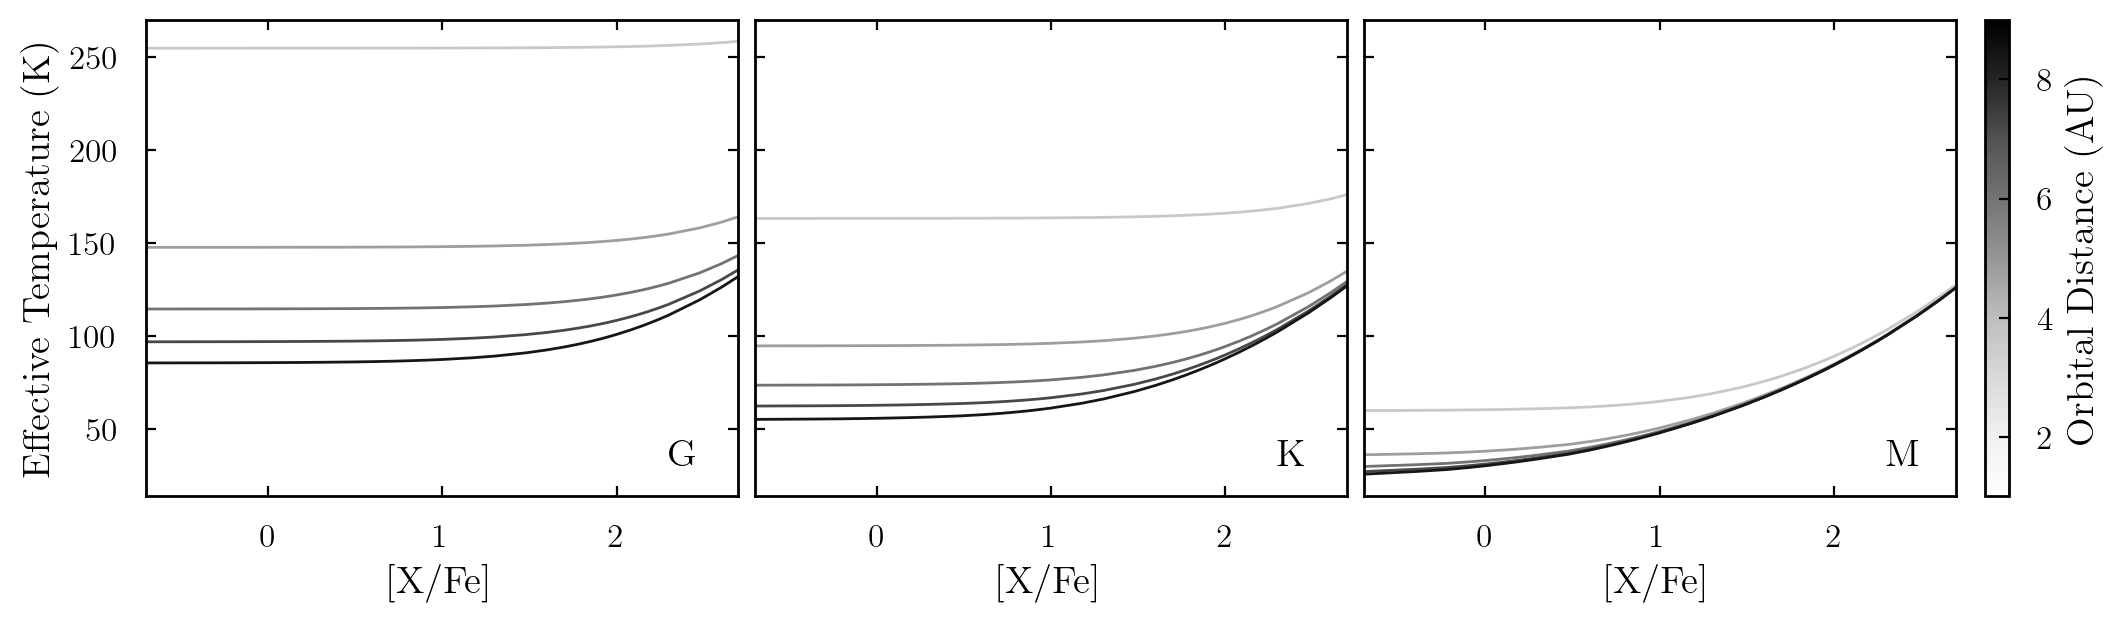

In [352]:
# now we combine the surface heat fluxes and stellar heat fluxes (with distance)
# to compute the total heat flux at the surface of a planet. 

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(10.5, 3), dpi=200, constrained_layout=True, sharey=True, sharex=True)
# for each of the data points in this scatter plot, we will have a range of distances for each stellar type.
#full_surf_heat_fluxes = []
#conc_1_mass = []
#ax1.set_yscale('log')
#ax2.set_yscale('log')
#ax3.set_yscale('log')
ax1.set_xlabel('[X/Fe]')
ax2.set_xlabel('[X/Fe]')
ax3.set_xlabel('[X/Fe]')
#ax1.set_ylabel(r'Surface Heat Flux (W/m$^2$)')
ax1.set_ylabel(r'Effective Temperature (K)')

# make a colormap for the distances 
G_dist_colors = plt.cm.Greys(np.linspace(0.25, 1, len(distances)))
K_dist_colors = plt.cm.Greys(np.linspace(0.25, 1, len(distances)))
M_dist_colors = plt.cm.Greys(np.linspace(0.25, 1, len(distances)))

dist_range = np.arange(1000, len(distances), 2000) # take every nth distance starting from index m

ref_time = 4.5 #Gyr

for dist, G_dist_color, K_dist_color, M_dist_color in zip(distances[dist_range], G_dist_colors[dist_range], K_dist_colors[dist_range], M_dist_colors[dist_range]):
    print(f"Distance: {dist} AU")
    G2V_stellar_flux = G2V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
    K5V_stellar_flux = K5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
    M5V_stellar_flux = M5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
    
    full_surf_heat_fluxes = []
    conc_1_mass = []
    for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
        if mass != 1.0: # only plot the files with concentration not equal to 1.0
            continue
        if concentration == 0.0:
            continue
        else:
        #find the index of the time closest to ref_time
            idx = (np.abs(time - ref_time)).argmin()
            full_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
            full_surf_heat_fluxes.append(full_surf_heat_flux)
            conc_1_mass.append(concentration)
            #ax.scatter(np.log10(concentration), full_surf_heat_flux + G2V_stellar_flux, c='black', s=5)
    # sort the conc_1_mass and full_surf_heat_fluxes lists by conc_1_mass
    conc_1_mass, full_surf_heat_fluxes = zip(*sorted(zip(conc_1_mass, full_surf_heat_fluxes)))
    conc_1_mass = np.array(conc_1_mass)
    full_surf_heat_fluxes = np.array(full_surf_heat_fluxes)

    # use heat_flux_to_T_eff to convert the total heat fluxes to effective temperatures and plot these instead!
    ax1.plot(np.log10(conc_1_mass), heat_flux_to_T_eff(full_surf_heat_fluxes + G2V_stellar_flux/4), c=G_dist_color, ls='-', lw=1.0, alpha=1.0)
    ax2.plot(np.log10(conc_1_mass), heat_flux_to_T_eff(full_surf_heat_fluxes + K5V_stellar_flux/4), c=K_dist_color, ls='-', lw=1.0, alpha=1.0)
    ax3.plot(np.log10(conc_1_mass), heat_flux_to_T_eff(full_surf_heat_fluxes + M5V_stellar_flux/4), c=M_dist_color, ls='-', lw=1.0, alpha=1.0)
    #ax1.fill_between(np.log10(conc_1_mass), full_surf_heat_fluxes + G2V_stellar_flux, y2=G2V_stellar_flux, color=G_dist_color, ls='-', lw=0.0, alpha=1.0)
    #ax2.fill_between(np.log10(conc_1_mass), full_surf_heat_fluxes + K5V_stellar_flux, y2=K5V_stellar_flux, color=K_dist_color, ls='-', lw=0.0, alpha=1.0)
    #ax3.fill_between(np.log10(conc_1_mass), full_surf_heat_fluxes + M5V_stellar_flux, y2=M5V_stellar_flux, color=M_dist_color, ls='-', lw=0.0, alpha=1.0)

# add a colorbar for the distances
# but make the colorbar reflect the trimmed colormap Greys 0.25 to 1.0.

sm = plt.cm.ScalarMappable(cmap='Greys', norm=plt.Normalize(vmin=distances[dist_range][0], vmax=distances[dist_range][-1])) 
cb = plt.colorbar(sm, ax=ax3, label='Orbital Distance (AU)')

ax1.set_xlim(np.log10(min(conc_1_mass)), np.log10(max(conc_1_mass)));

# add text labels for each plot:
# G, K, M stars / (a) (b) (c)
ax1.text(s='G',x=2.3, y=30, fontsize=14)
ax2.text(s='K',x=2.3, y=30, fontsize=14)
ax3.text(s='M',x=2.3, y=30, fontsize=14)

Distance: 1.009099909990999 AU
Distance: 3.007299729972997 AU
Distance: 5.005499549954995 AU
Distance: 7.003699369936993 AU
Distance: 9.00189918991899 AU


Text(2.3, 0.05, 'M')

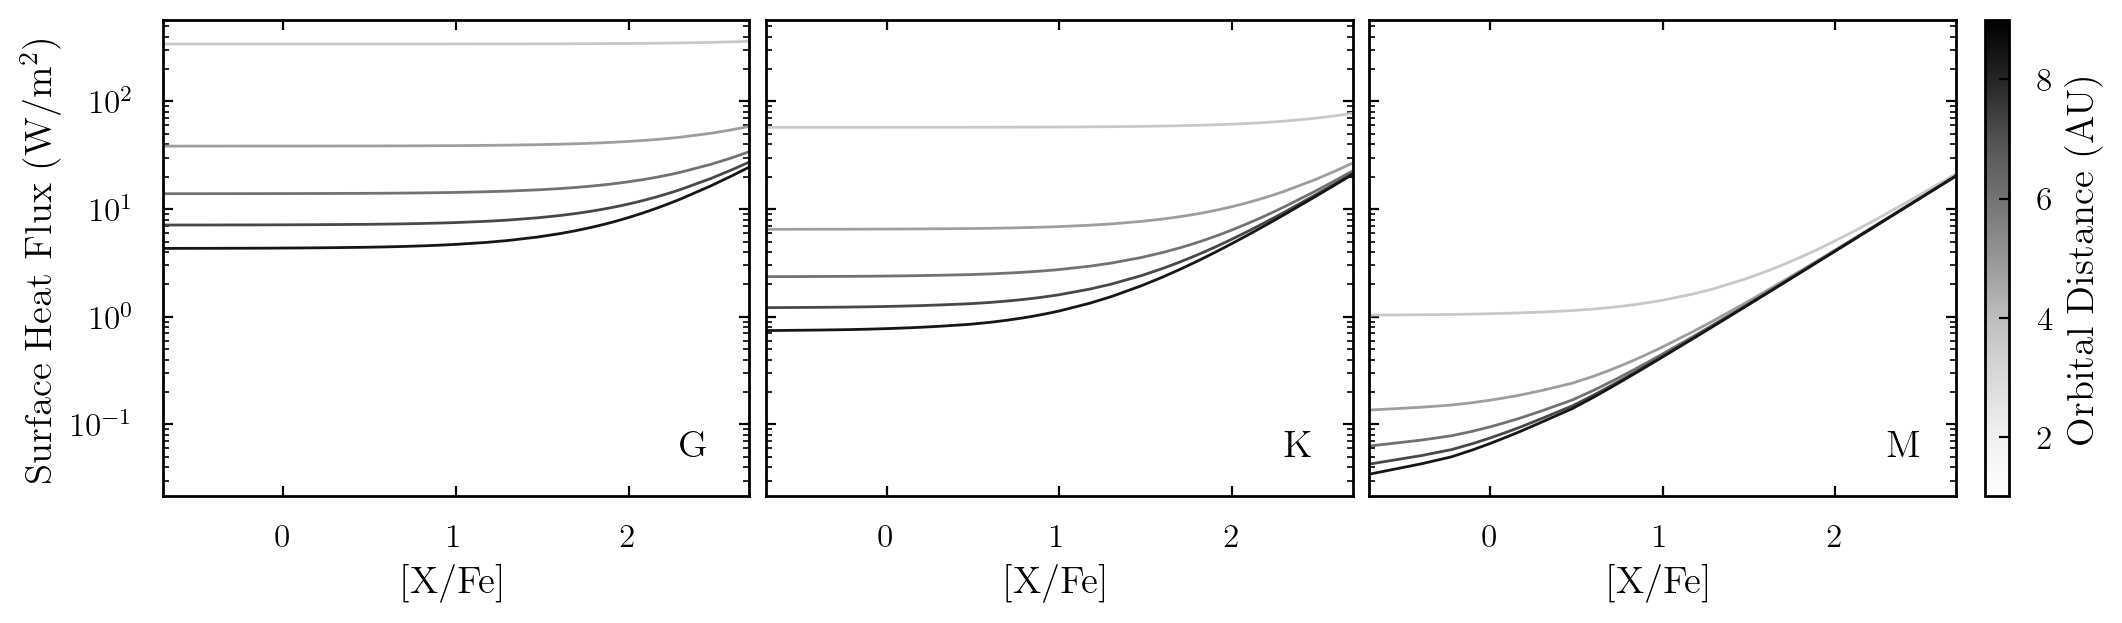

In [353]:
# now we combine the surface heat fluxes and stellar heat fluxes (with distance)
# to compute the total heat flux at the surface of a planet. 

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(10.5, 3), dpi=200, constrained_layout=True, sharey=True, sharex=True)
# for each of the data points in this scatter plot, we will have a range of distances for each stellar type.
#full_surf_heat_fluxes = []
#conc_1_mass = []
ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')
ax1.set_xlabel('[X/Fe]')
ax2.set_xlabel('[X/Fe]')
ax3.set_xlabel('[X/Fe]')
ax1.set_ylabel(r'Surface Heat Flux (W/m$^2$)')
#ax1.set_ylabel(r'Effective Temperature (K)')

# make a colormap for the distances 
G_dist_colors = plt.cm.Greys(np.linspace(0.25, 1, len(distances)))
K_dist_colors = plt.cm.Greys(np.linspace(0.25, 1, len(distances)))
M_dist_colors = plt.cm.Greys(np.linspace(0.25, 1, len(distances)))

dist_range = np.arange(1000, len(distances), 2000) # take every nth distance starting from index m

ref_time = 4.5 #Gyr

for dist, G_dist_color, K_dist_color, M_dist_color in zip(distances[dist_range], G_dist_colors[dist_range], K_dist_colors[dist_range], M_dist_colors[dist_range]):
    print(f"Distance: {dist} AU")
    G2V_stellar_flux = G2V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
    K5V_stellar_flux = K5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
    M5V_stellar_flux = M5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
    
    full_surf_heat_fluxes = []
    conc_1_mass = []
    for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
        if mass != 1.0: # only plot the files with concentration not equal to 1.0
            continue
        if concentration == 0.0:
            continue
        else:
        #find the index of the time closest to ref_time
            idx = (np.abs(time - ref_time)).argmin()
            full_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
            full_surf_heat_fluxes.append(full_surf_heat_flux)
            conc_1_mass.append(concentration)
            #ax.scatter(np.log10(concentration), full_surf_heat_flux + G2V_stellar_flux, c='black', s=5)
    # sort the conc_1_mass and full_surf_heat_fluxes lists by conc_1_mass
    conc_1_mass, full_surf_heat_fluxes = zip(*sorted(zip(conc_1_mass, full_surf_heat_fluxes)))
    conc_1_mass = np.array(conc_1_mass)
    full_surf_heat_fluxes = np.array(full_surf_heat_fluxes)

    # use heat_flux_to_T_eff to convert the total heat fluxes to effective temperatures and plot these instead!
    ax1.plot(np.log10(conc_1_mass), full_surf_heat_fluxes + G2V_stellar_flux/4, c=G_dist_color, ls='-', lw=1.0, alpha=1.0)
    ax2.plot(np.log10(conc_1_mass), full_surf_heat_fluxes + K5V_stellar_flux/4, c=K_dist_color, ls='-', lw=1.0, alpha=1.0)
    ax3.plot(np.log10(conc_1_mass), full_surf_heat_fluxes + M5V_stellar_flux/4, c=M_dist_color, ls='-', lw=1.0, alpha=1.0)
    #ax1.fill_between(np.log10(conc_1_mass), full_surf_heat_fluxes + G2V_stellar_flux, y2=G2V_stellar_flux, color=G_dist_color, ls='-', lw=0.0, alpha=1.0)
    #ax2.fill_between(np.log10(conc_1_mass), full_surf_heat_fluxes + K5V_stellar_flux, y2=K5V_stellar_flux, color=K_dist_color, ls='-', lw=0.0, alpha=1.0)
    #ax3.fill_between(np.log10(conc_1_mass), full_surf_heat_fluxes + M5V_stellar_flux, y2=M5V_stellar_flux, color=M_dist_color, ls='-', lw=0.0, alpha=1.0)

# add a colorbar for the distances
# but make the colorbar reflect the trimmed colormap Greys 0.25 to 1.0.

sm = plt.cm.ScalarMappable(cmap='Greys', norm=plt.Normalize(vmin=distances[dist_range][0], vmax=distances[dist_range][-1])) 
cb = plt.colorbar(sm, ax=ax3, label='Orbital Distance (AU)')

ax1.set_xlim(np.log10(min(conc_1_mass)), np.log10(max(conc_1_mass)));

# add text labels for each plot:
# G, K, M stars / (a) (b) (c)
ax1.text(s='G',x=2.3, y=5e-2, fontsize=14)
ax2.text(s='K',x=2.3, y=5e-2, fontsize=14)
ax3.text(s='M',x=2.3, y=5e-2, fontsize=14)

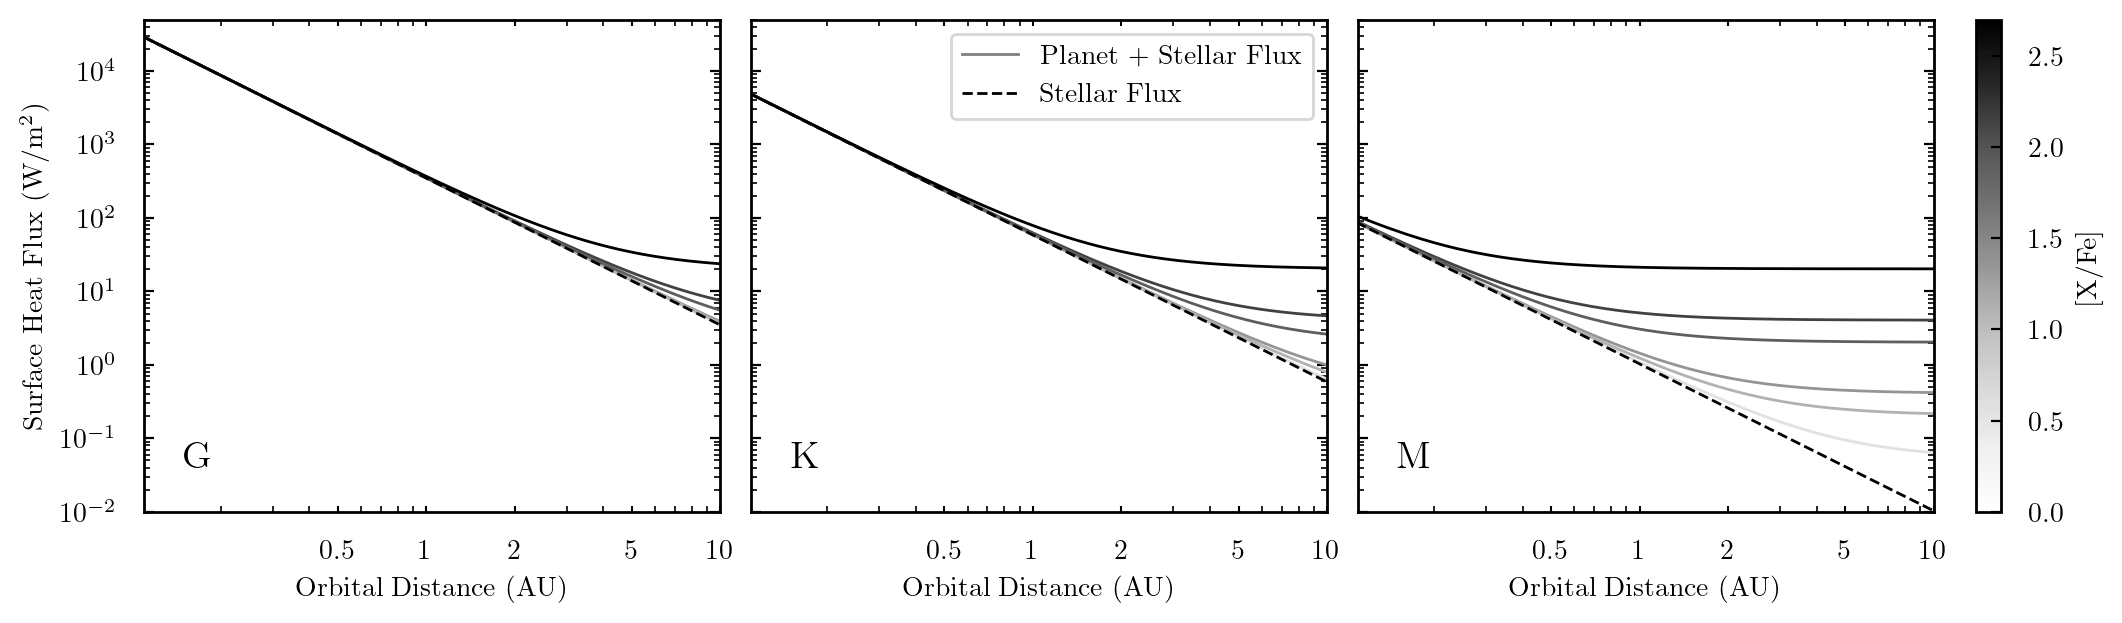

In [565]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(10.5, 3), dpi=200, constrained_layout=True, sharey=True, sharex=True)
# for each of the data points in this scatter plot, we will have a range of distances for each stellar type.
#full_surf_heat_fluxes = []
#conc_1_mass = []
ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')
ax1.set_xlabel('Orbital Distance (AU)')
ax2.set_xlabel('Orbital Distance (AU)')
ax3.set_xlabel('Orbital Distance (AU)')
ax1.set_ylabel(r'Surface Heat Flux (W/m$^2$)')

# make a colormap for the concentrations
norm = plt.Normalize(
    vmin=np.log10(concentrations[concentrations > 0]).min(),
    vmax=np.log10(concentrations[concentrations > 0]).max()
)

cmap = plt.cm.Greys
dist_range = np.arange(100, len(distances), 10) # take every nth distance starting from index m

ref_time = 4.5 #Gyr

full_surf_heat_fluxes = []
conc_1_mass = []

for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux, in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
    if mass != 1.0: # only plot the files with concentration not equal to 1.0
        continue
    if concentration == 0.0:
        continue
    if concentration not in [0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]: # only plot the files with concentration in this list
        continue
    else:
    #find the index of the time closest to ref_time
        idx = (np.abs(time - ref_time)).argmin()
        full_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
        full_surf_heat_fluxes.append(full_surf_heat_flux)
        conc_1_mass.append(np.log10(concentration))

    conc_color = cmap(norm(np.log10(concentration)))

    distances_for_plot = []
    sum_g_fluxes_for_plot = []
    sum_k_fluxes_for_plot = []
    sum_m_fluxes_for_plot = []

    for dist in distances[dist_range]:
        #print(f"Distance: {dist} AU")
        G2V_stellar_flux = G2V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
        K5V_stellar_flux = K5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
        M5V_stellar_flux = M5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]

        distances_for_plot.append(dist)

        sum_g_flux = full_surf_heat_flux + G2V_stellar_flux / 4
        sum_k_flux = full_surf_heat_flux + K5V_stellar_flux / 4 
        sum_m_flux = full_surf_heat_flux + M5V_stellar_flux / 4

        sum_g_fluxes_for_plot.append(sum_g_flux)
        sum_k_fluxes_for_plot.append(sum_k_flux)
        sum_m_fluxes_for_plot.append(sum_m_flux)

        #ax1.scatter(dist, sum_g_flux, c=conc_color, s=5)
        #ax2.scatter(dist, sum_k_flux, c=conc_color, s=5)
        #ax3.scatter(dist, sum_m_flux, c=conc_color, s=5)

    # can we smooth the curves 
    ax1.plot(distances_for_plot, sum_g_fluxes_for_plot, c=conc_color, ls='-', lw=1.0, alpha=1.0)
    ax2.plot(distances_for_plot, sum_k_fluxes_for_plot, c=conc_color, ls='-', lw=1.0, alpha=1.0)
    ax3.plot(distances_for_plot, sum_m_fluxes_for_plot, c=conc_color, ls='-', lw=1.0, alpha=1.0)

ax1.plot(distances,G2V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)
ax2.plot(distances,K5V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)
ax3.plot(distances,M5V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)

# make fake data points for the sum lines
ax2.plot([],[],label='Planet + Stellar Flux', ls='-', lw=1, c='Grey')
ax2.plot([],[],label='Stellar Flux', ls='--', lw=1, c='k')
ax2.legend(loc='upper right',fontsize=10)

# add a colorbar for the concentrations
# but make the colorbar reflect the trimmed colormap Greys 0.25 to 1.0.
sm = plt.cm.ScalarMappable(cmap='Greys', norm=plt.Normalize(vmin=min(conc_1_mass), vmax=max(conc_1_mass)))
cb = plt.colorbar(sm, ax=ax3, label='[X/Fe]')

ax1.set_xlim(min(distances_for_plot), max(distances_for_plot));
#ax1.set_ylim(np.log10(min(conc_1_mass)), np.log10(max(conc_1_mass)));
ax1.set_ylim(1e-2,5e4)
ax1.set_xscale('log');

# make tick labels for the x-axis 0.5, 1, 2, 5, 10 AU
# but make them integers, not floats
ax1.set_xticks([0.5, 1, 2, 5, 10])
ax1.set_xticklabels(['0.5', '1', '2', '5', '10']);
# but make their tick markers smaller
ax1.tick_params(axis='x', which='major', length=2, width=0.75)
ax2.tick_params(axis='x', which='major', length=2, width=0.75)
ax3.tick_params(axis='x', which='major', length=2, width=0.75)

# add text labels for each plot:
# G, K, M stars / (a) (b) (c)
ax1.text(s='G',x=0.15, y=4e-2, fontsize=14)
ax2.text(s='K',x=0.15, y=4e-2, fontsize=14)
ax3.text(s='M',x=0.15, y=4e-2, fontsize=14)
print();
#ax1.set_ylim(1e-2,1e3)

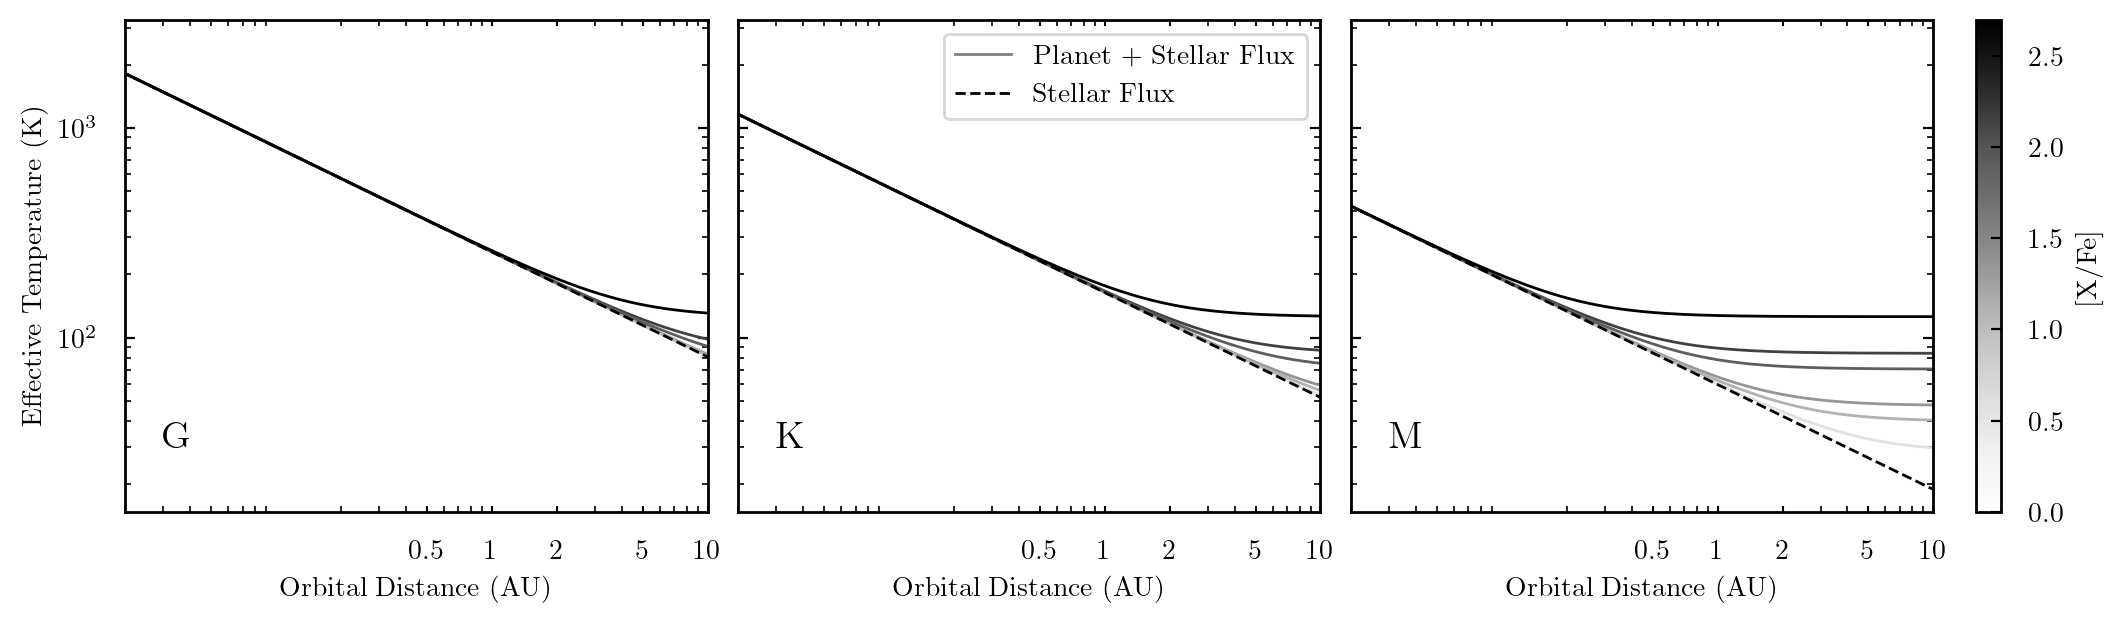

In [568]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(10.5, 3), dpi=200, constrained_layout=True, sharey=True, sharex=True)
# for each of the data points in this scatter plot, we will have a range of distances for each stellar type.
#full_surf_heat_fluxes = []
#conc_1_mass = []
#ax1.set_yscale('log')
#ax2.set_yscale('log')
#ax3.set_yscale('log')
ax1.set_xlabel('Orbital Distance (AU)')
ax2.set_xlabel('Orbital Distance (AU)')
ax3.set_xlabel('Orbital Distance (AU)')
#ax1.set_ylabel(r'Surface Heat Flux (W/m$^2$)')
ax1.set_ylabel(r'Effective Temperature (K)')

# make a colormap for the concentrations
norm = plt.Normalize(
    vmin=np.log10(concentrations[concentrations > 0]).min(),
    vmax=np.log10(concentrations[concentrations > 0]).max()
)

cmap = plt.cm.Greys
dist_range = np.arange(10, len(distances), 10) # take every nth distance starting from index m

ref_time = 4.5 #Gyr

full_surf_heat_fluxes = []
conc_1_mass = []

for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux, in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
    if mass != 1.0: # only plot the files with concentration not equal to 1.0
        continue
    if concentration == 0.0:
        continue
    if concentration not in [0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]: # only plot the files with concentration in this list
        continue
    else:
    #find the index of the time closest to ref_time
        idx = (np.abs(time - ref_time)).argmin()
        full_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
        full_surf_heat_fluxes.append(full_surf_heat_flux)
        conc_1_mass.append(np.log10(concentration))

    conc_color = cmap(norm(np.log10(concentration)))

    distances_for_plot = []
    sum_g_fluxes_for_plot = []
    sum_k_fluxes_for_plot = []
    sum_m_fluxes_for_plot = []

    for dist in distances[dist_range]:
        #print(f"Distance: {dist} AU")
        G2V_stellar_flux = G2V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
        K5V_stellar_flux = K5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
        M5V_stellar_flux = M5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]

        distances_for_plot.append(dist)

        sum_g_flux = full_surf_heat_flux + G2V_stellar_flux / 4
        sum_k_flux = full_surf_heat_flux + K5V_stellar_flux / 4 
        sum_m_flux = full_surf_heat_flux + M5V_stellar_flux / 4

        sum_g_fluxes_for_plot.append(sum_g_flux)
        sum_k_fluxes_for_plot.append(sum_k_flux)
        sum_m_fluxes_for_plot.append(sum_m_flux)

        #ax1.scatter(dist, sum_g_flux, c=conc_color, s=5)
        #ax2.scatter(dist, sum_k_flux, c=conc_color, s=5)
        #ax3.scatter(dist, sum_m_flux, c=conc_color, s=5)
    sum_g_fluxes_for_plot = np.array(sum_g_fluxes_for_plot)
    sum_k_fluxes_for_plot = np.array(sum_k_fluxes_for_plot)
    sum_m_fluxes_for_plot = np.array(sum_m_fluxes_for_plot)

    ax1.plot(distances_for_plot, heat_flux_to_T_eff(sum_g_fluxes_for_plot), c=conc_color, ls='-', lw=1.0, alpha=1.0)
    ax2.plot(distances_for_plot, heat_flux_to_T_eff(sum_k_fluxes_for_plot), c=conc_color, ls='-', lw=1.0, alpha=1.0)
    ax3.plot(distances_for_plot, heat_flux_to_T_eff(sum_m_fluxes_for_plot), c=conc_color, ls='-', lw=1.0, alpha=1.0)

ax1.plot(distances,heat_flux_to_T_eff(G2V_stellar_fluxes_log_interp_values/4), c='black', ls='--', lw=1.0)
ax2.plot(distances,heat_flux_to_T_eff(K5V_stellar_fluxes_log_interp_values/4), c='black', ls='--', lw=1.0)
ax3.plot(distances,heat_flux_to_T_eff(M5V_stellar_fluxes_log_interp_values/4), c='black', ls='--', lw=1.0)

# make fake data points for the sum lines
ax2.plot([],[],label='Planet + Stellar Flux', ls='-', lw=1, c='Grey')
ax2.plot([],[],label='Stellar Flux', ls='--', lw=1, c='k')
ax2.legend(loc='upper right',fontsize=10)

# add a colorbar for the concentrations
# but make the colorbar reflect the trimmed colormap Greys 0.25 to 1.0.
sm = plt.cm.ScalarMappable(cmap='Greys', norm=plt.Normalize(vmin=min(conc_1_mass), vmax=max(conc_1_mass)))
cb = plt.colorbar(sm, ax=ax3, label='[X/Fe]')

ax1.set_xlim(min(distances_for_plot), max(distances_for_plot));
#ax1.set_ylim(np.log10(min(conc_1_mass)), np.log10(max(conc_1_mass)));
ax1.set_xscale('log');

# make tick labels for the x-axis 0.5, 1, 2, 5, 10 AU
# but make them integers, not floats
ax1.set_xticks([0.5, 1, 2, 5, 10])
ax1.set_xticklabels(['0.5', '1', '2', '5', '10']);
# but make their tick markers smaller
ax1.tick_params(axis='x', which='major', length=2, width=0.75)
ax2.tick_params(axis='x', which='major', length=2, width=0.75)
ax3.tick_params(axis='x', which='major', length=2, width=0.75)

# add text labels for each plot:
# G, K, M stars / (a) (b) (c)
ax1.text(s='G',x=0.03, y=30, fontsize=14)
ax2.text(s='K',x=0.03, y=30, fontsize=14)
ax3.text(s='M',x=0.03, y=30, fontsize=14)
print();
#ax1.set_ylim(1e-2,1000)
#ax1.set_xscale('linear')
ax1.set_yscale('log')

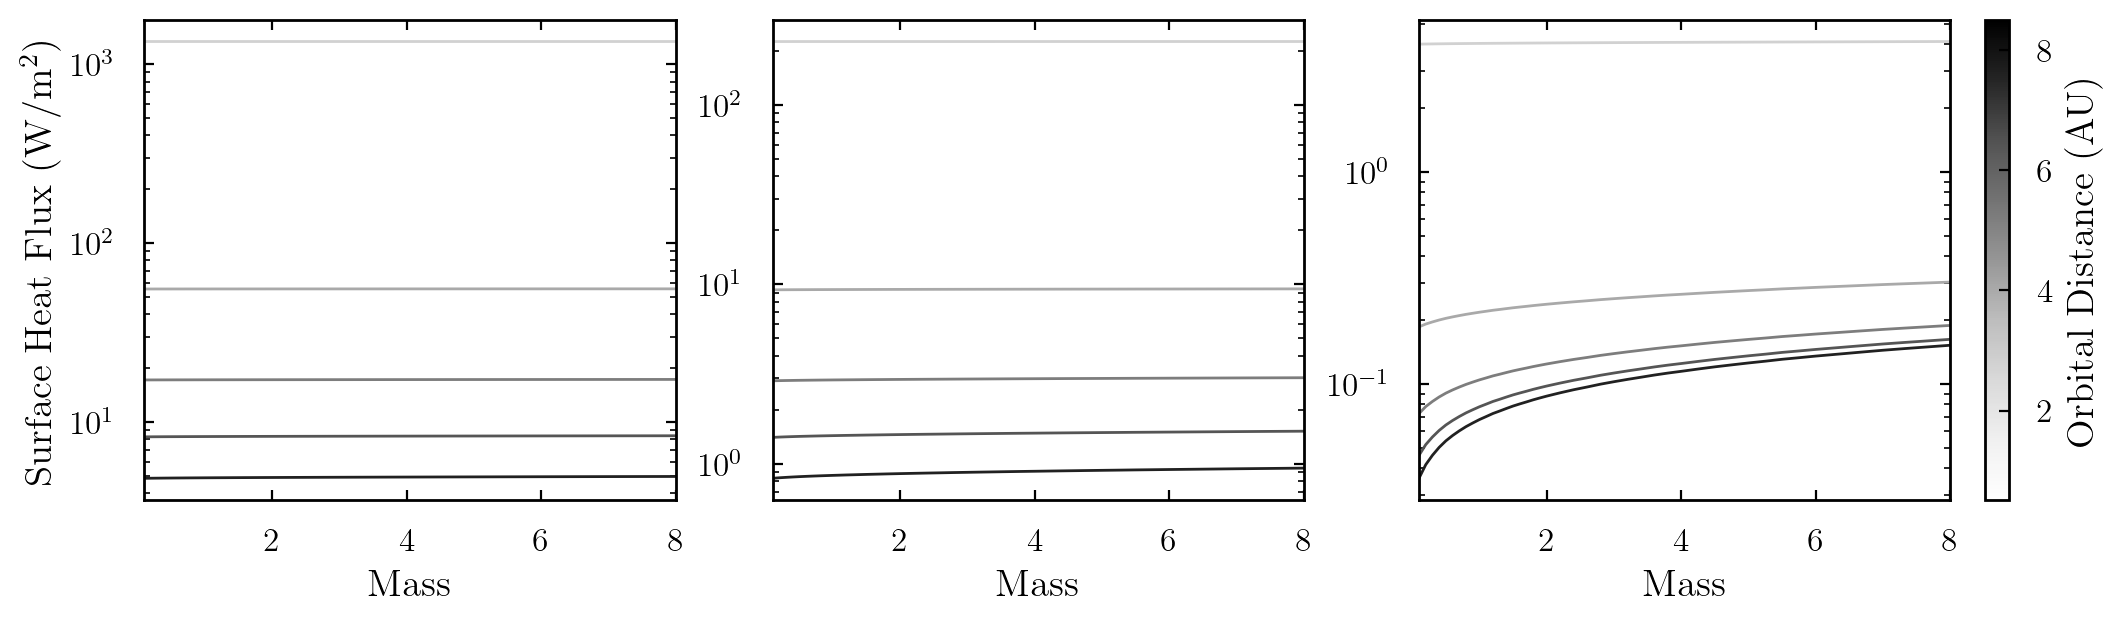

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(10.5, 3), dpi=200, constrained_layout=True, sharex=True)
# for each of the data points in this scatter plot, we will have a range of distances for each stellar type.
#full_surf_heat_fluxes = []
#conc_1_mass = []
ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')
ax1.set_xlabel('Mass')
ax2.set_xlabel('Mass')
ax3.set_xlabel('Mass')
ax1.set_ylabel(r'Surface Heat Flux (W/m$^2$)')

# make a colormap for the distances 
G_dist_colors = plt.cm.Greys(np.linspace(0.25, 1, len(distances)))
K_dist_colors = plt.cm.Greys(np.linspace(0.25, 1, len(distances)))
M_dist_colors = plt.cm.Greys(np.linspace(0.25, 1, len(distances)))

dist_range = np.arange(500, len(distances), 2000) # take every nth distance starting from index m

ref_time = 4.5 #Gyr

for dist, G_dist_color, K_dist_color, M_dist_color in zip(distances[dist_range], G_dist_colors[dist_range], K_dist_colors[dist_range], M_dist_colors[dist_range]):
    #print(f"Distance: {dist} AU")
    G2V_stellar_flux = G2V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
    K5V_stellar_flux = K5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
    M5V_stellar_flux = M5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]

    full_surface_heat_fluxes = []
    mass_1_conc = []

    for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
        if concentration != 1.0: # only plot the files with concentration not equal to 1.0
            continue
        else:
            # find the index of the time closest to ref_time
            idx = (np.abs(time - ref_time)).argmin()
            full_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
            #ax1.scatter(mass, full_surf_heat_flux + G2V_stellar_flux, c='black', s=8)
            #ax2.scatter(mass, full_surf_heat_flux + K5V_stellar_flux, c='black', s=8)
            #ax3.scatter(mass, full_surf_heat_flux + M5V_stellar_flux, c='black', s=8)

            mass_1_conc.append(mass)
            full_surface_heat_fluxes.append(full_surf_heat_flux)

    mass_1_conc, full_surface_heat_fluxes = zip(*sorted(zip(mass_1_conc, full_surface_heat_fluxes)))
    mass_1_conc = np.array(mass_1_conc)
    full_surface_heat_fluxes = np.array(full_surface_heat_fluxes)
    #ax1.plot(mass_1_conc, full_surface_heat_fluxes * 0 + G2V_stellar_flux / 4, c=G_dist_color, ls='--', lw=1.0, alpha=1.0)
    ax1.plot(mass_1_conc, full_surface_heat_fluxes + G2V_stellar_flux /4, c=G_dist_color, ls='-', lw=1.0, alpha=1.0)
    #ax2.plot(mass_1_conc, full_surface_heat_fluxes * 0 + K5V_stellar_flux / 4, c=G_dist_color, ls='--', lw=1.0, alpha=1.0)
    ax2.plot(mass_1_conc, full_surface_heat_fluxes + K5V_stellar_flux /4, c=K_dist_color, ls='-', lw=1.0, alpha=1.0)
    #ax3.plot(mass_1_conc, full_surface_heat_fluxes * 0 + M5V_stellar_flux / 4, c=G_dist_color, ls='--', lw=1.0, alpha=1.0)
    ax3.plot(mass_1_conc, full_surface_heat_fluxes + M5V_stellar_flux /4, c=M_dist_color, ls='-', lw=1.0, alpha=1.0)
    #ax1.fill_between(mass_1_conc, full_surface_heat_fluxes + G2V_stellar_flux, y2=G2V_stellar_flux, color=G_dist_color, ls='-', lw=0.0, alpha=1.0)
    #ax2.fill_between(mass_1_conc, full_surface_heat_fluxes + K5V_stellar_flux, y2=K5V_stellar_flux, color=K_dist_color, ls='-', lw=0.0, alpha=1.0)
    #ax3.fill_between(mass_1_conc, full_surface_heat_fluxes + M5V_stellar_flux, y2=M5V_stellar_flux, color=M_dist_color, ls='-', lw=0.0, alpha=1.0)

# add a colorbar for the distances
sm = plt.cm.ScalarMappable(cmap='Greys', norm=plt.Normalize(vmin=distances[dist_range][0], vmax=distances[dist_range][-1])) 
cb = plt.colorbar(sm, ax=ax3, label='Orbital Distance (AU)')

ax1.set_xlim((min(mass_1_conc)),(max(mass_1_conc)));


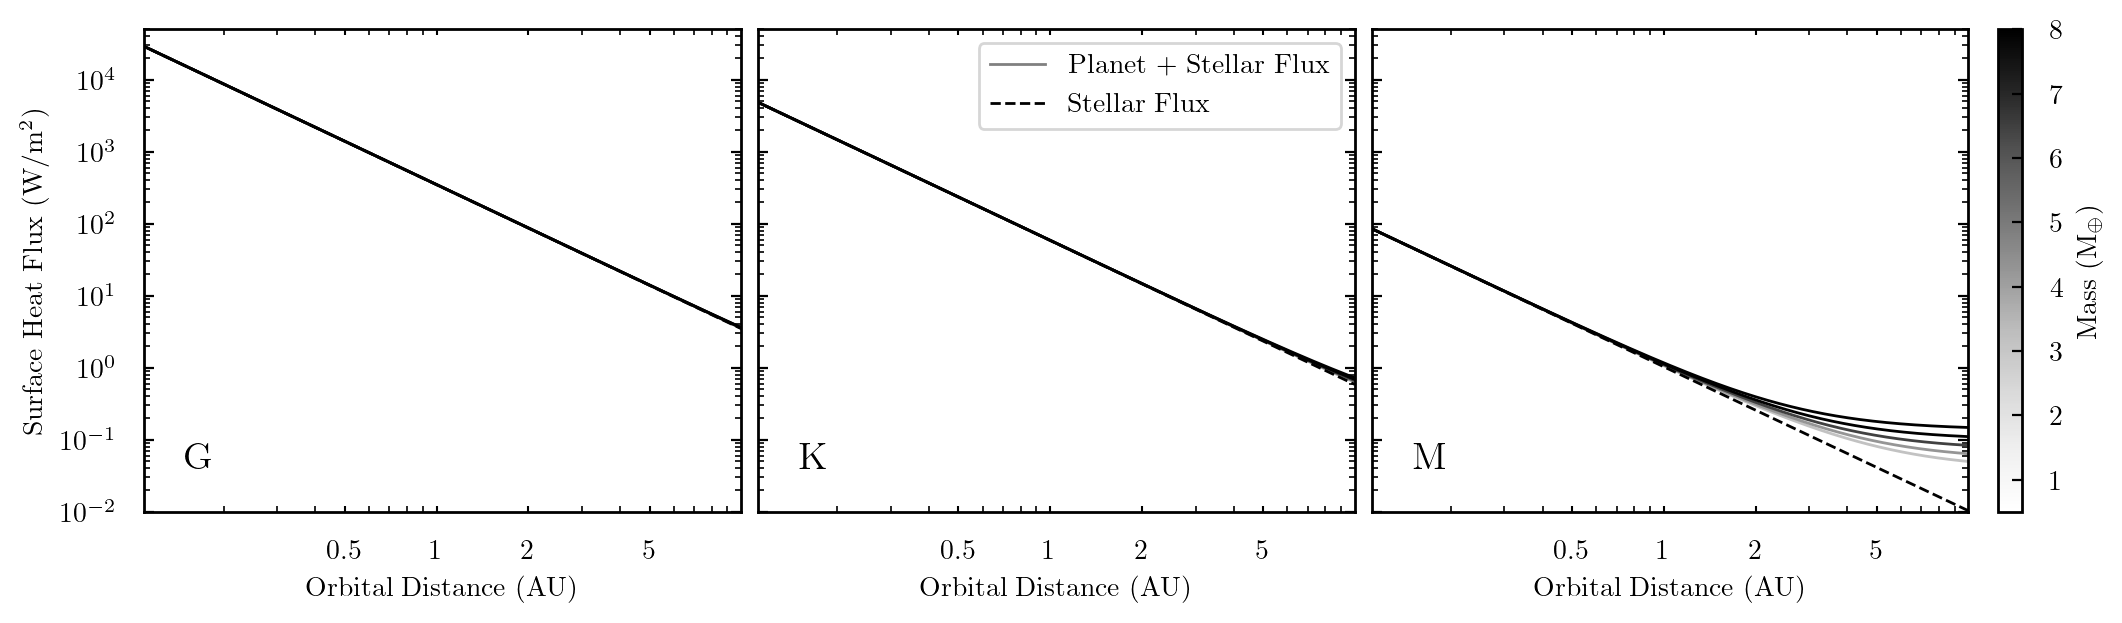

In [ ]:
# now do it again for mass, at a fixed concentration.

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(10.5, 3), dpi=200, constrained_layout=True, sharey=True, sharex=True)
# for each of the data points in this scatter plot, we will have a range of distances for each stellar type.
#full_surf_heat_fluxes = []
#conc_1_mass = []
ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')
ax1.set_xlabel('Orbital Distance (AU)')
ax2.set_xlabel('Orbital Distance (AU)')
ax3.set_xlabel('Orbital Distance (AU)')
ax1.set_ylabel(r'Surface Heat Flux (W/m$^2$)')

ax1.set_xscale('log');

# make tick labels for the x-axis 0.5, 1, 2, 5, 10 AU
# but make them integers, not floats
ax1.set_xticks([0.5, 1, 2, 5, 10])
ax1.set_xticklabels(['0.5', '1', '2', '5', '10']);
# but make their tick markers smaller
ax1.tick_params(axis='x', which='major', length=2, width=0.75)
ax2.tick_params(axis='x', which='major', length=2, width=0.75)
ax3.tick_params(axis='x', which='major', length=2, width=0.75)

# make a colormap for the concentrations
norm = plt.Normalize(
    vmin=np.log10(concentrations[concentrations > 0]).min(),
    vmax=np.log10(concentrations[concentrations > 0]).max()
)

cmap = plt.cm.Greys
dist_range = np.arange(100, len(distances), 10) # take every nth distance starting from index m

ref_time = 4.5 #Gyr

full_surf_heat_fluxes = []
mass_1_conc = []

for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux, in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
    if concentration != 1.0:
        continue
    if mass not in [0.5, 1.0, 2.0, 4.0, 8.0]:
        continue
    else:
    #find the index of the time closest to ref_time
        idx = (np.abs(time - ref_time)).argmin()
        full_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
        full_surf_heat_fluxes.append(full_surf_heat_flux)
        mass_1_conc.append((mass))
    
    mass_color = cmap(norm((mass))) 

    distances_for_plot = []
    sum_g_fluxes_for_plot = []
    sum_k_fluxes_for_plot = []
    sum_m_fluxes_for_plot = []

    for dist in distances[dist_range]:
        #print(f"Distance: {dist} AU")
        G2V_stellar_flux = G2V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
        K5V_stellar_flux = K5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
        M5V_stellar_flux = M5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]

        distances_for_plot.append(dist)

        sum_g_flux = full_surf_heat_flux + G2V_stellar_flux / 4
        sum_k_flux = full_surf_heat_flux + K5V_stellar_flux / 4
        sum_m_flux = full_surf_heat_flux + M5V_stellar_flux / 4

        sum_g_fluxes_for_plot.append(sum_g_flux)
        sum_k_fluxes_for_plot.append(sum_k_flux)
        sum_m_fluxes_for_plot.append(sum_m_flux)

        #ax1.scatter(dist, sum_g_flux, c=conc_color, s=5)
        #ax2.scatter(dist, sum_k_flux, c=conc_color, s=5)
        #ax3.scatter(dist, sum_m_flux, c=conc_color, s=5)

    # can we smooth the curves 

    ax1.plot(distances_for_plot, sum_g_fluxes_for_plot, c=mass_color, ls='-', lw=1.0, alpha=1.0)
    ax2.plot(distances_for_plot, sum_k_fluxes_for_plot, c=mass_color, ls='-', lw=1.0, alpha=1.0)
    ax3.plot(distances_for_plot, sum_m_fluxes_for_plot, c=mass_color, ls='-', lw=1.0, alpha=1.0)


ax1.plot(distances,G2V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)
ax2.plot(distances,K5V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)
ax3.plot(distances,M5V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)

# make fake data points for the sum lines
ax2.plot([],[],label='Planet + Stellar Flux', ls='-', lw=1, c='Grey')
ax2.plot([],[],label='Stellar Flux', ls='--', lw=1, c='k')
ax2.legend(loc='upper right', fontsize=10)

# add a colorbar for the concentrations
# but make the colorbar reflect the trimmed colormap Greys 0.25 to 1.0.

sm = plt.cm.ScalarMappable(cmap='Greys', norm=plt.Normalize(vmin=min(mass_1_conc), vmax=max(mass_1_conc)))
cb = plt.colorbar(sm, ax=ax3, label=r'Mass ($\rm{M_{\oplus}}$)')

ax1.set_xlim(min(distances_for_plot), max(distances_for_plot));
ax1.set_ylim(1e-2,5e4)

# add text labels for each plot:
# G, K, M stars / (a) (b) (c)
ax1.text(s='G',x=0.15, y=4e-2, fontsize=14)
ax2.text(s='K',x=0.15, y=4e-2, fontsize=14)
ax3.text(s='M',x=0.15, y=4e-2, fontsize=14);

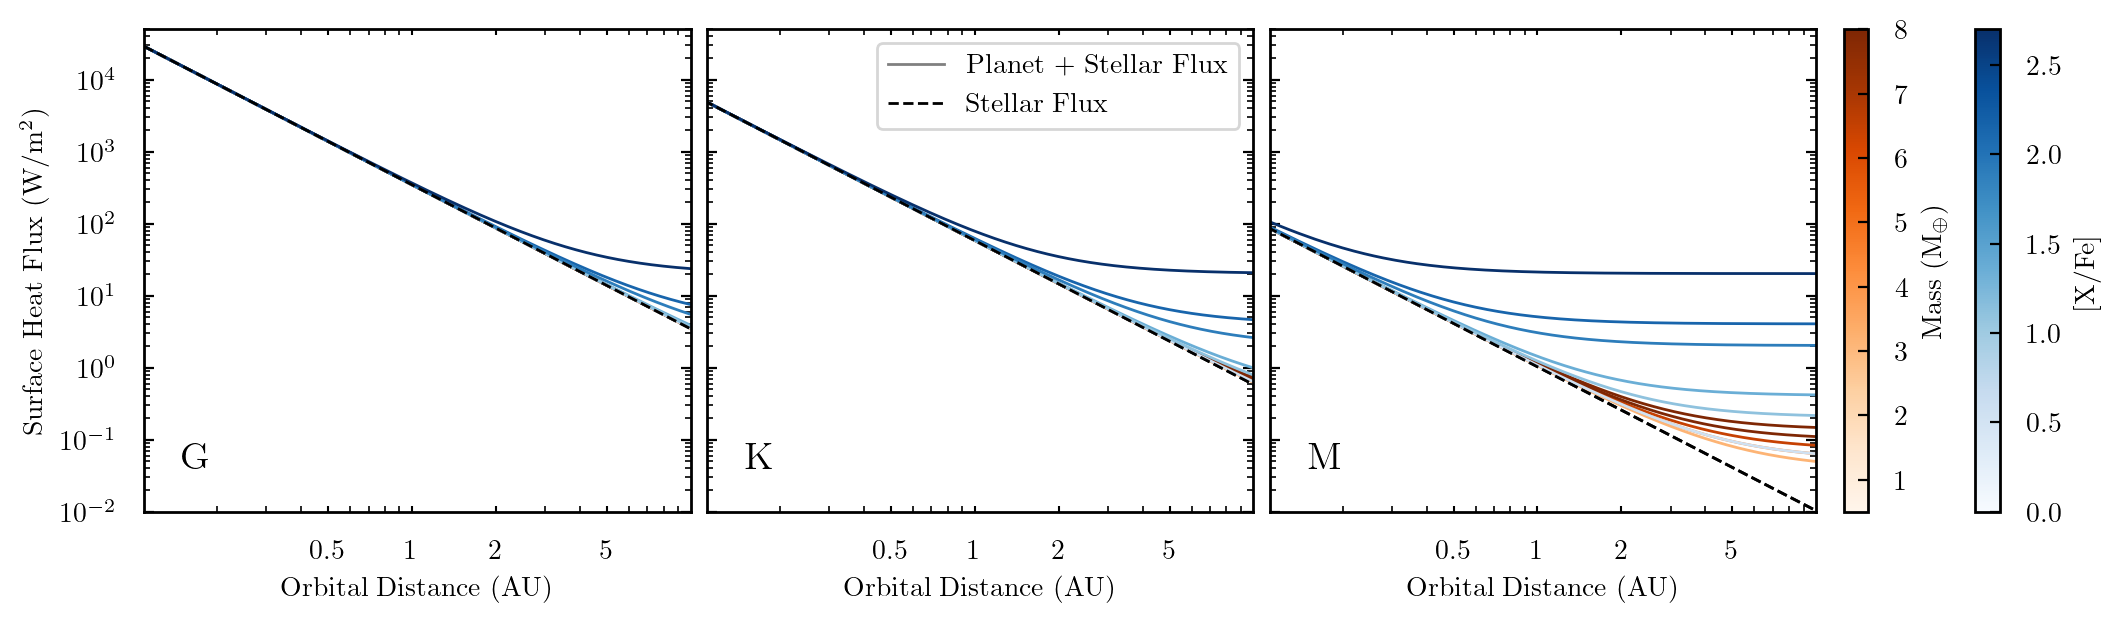

In [642]:
### Plot both X/Fe and M on the same set of plots
# now do it again for mass, at a fixed concentration.

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(10.5, 3), dpi=200, constrained_layout=True, sharey=True, sharex=True)
# for each of the data points in this scatter plot, we will have a range of distances for each stellar type.
#full_surf_heat_fluxes = []
#conc_1_mass = []
ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')
ax1.set_xlabel('Orbital Distance (AU)')
ax2.set_xlabel('Orbital Distance (AU)')
ax3.set_xlabel('Orbital Distance (AU)')
ax1.set_ylabel(r'Surface Heat Flux (W/m$^2$)')

ax1.set_xscale('log');

# make tick labels for the x-axis 0.5, 1, 2, 5, 10 AU
# but make them integers, not floats
ax1.set_xticks([0.5, 1, 2, 5, 10])
ax1.set_xticklabels(['0.5', '1', '2', '5', '10']);
# but make their tick markers smaller
ax1.tick_params(axis='x', which='major', length=2, width=0.75)
ax2.tick_params(axis='x', which='major', length=2, width=0.75)
ax3.tick_params(axis='x', which='major', length=2, width=0.75)

# make a colormap for the concentrations
norm = plt.Normalize(
    vmin=np.log10(concentrations[concentrations > 0]).min(),
    vmax=np.log10(concentrations[concentrations > 0]).max()
)

cmap = plt.cm.Oranges
dist_range = np.arange(100, len(distances), 10) # take every nth distance starting from index m

ref_time = 4.5 #Gyr

full_surf_heat_fluxes = []
mass_1_conc = []

for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux, in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
    if concentration != 1.0:
        continue
    if mass not in [0.5, 1.0, 2.0, 4.0, 8.0]:
        continue
    else:
    #find the index of the time closest to ref_time
        idx = (np.abs(time - ref_time)).argmin()
        full_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
        full_surf_heat_fluxes.append(full_surf_heat_flux)
        mass_1_conc.append((mass))
    
    mass_color = cmap(norm((mass))) 

    distances_for_plot = []
    sum_g_fluxes_for_plot = []
    sum_k_fluxes_for_plot = []
    sum_m_fluxes_for_plot = []

    for dist in distances[dist_range]:
        #print(f"Distance: {dist} AU")
        G2V_stellar_flux = G2V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
        K5V_stellar_flux = K5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
        M5V_stellar_flux = M5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]

        distances_for_plot.append(dist)

        sum_g_flux = full_surf_heat_flux + G2V_stellar_flux / 4
        sum_k_flux = full_surf_heat_flux + K5V_stellar_flux / 4
        sum_m_flux = full_surf_heat_flux + M5V_stellar_flux / 4

        sum_g_fluxes_for_plot.append(sum_g_flux)
        sum_k_fluxes_for_plot.append(sum_k_flux)
        sum_m_fluxes_for_plot.append(sum_m_flux)

        #ax1.scatter(dist, sum_g_flux, c=conc_color, s=5)
        #ax2.scatter(dist, sum_k_flux, c=conc_color, s=5)
        #ax3.scatter(dist, sum_m_flux, c=conc_color, s=5)

    # can we smooth the curves 

    ax1.plot(distances_for_plot, sum_g_fluxes_for_plot, c=mass_color, ls='-', lw=1.0, alpha=1.0)
    ax2.plot(distances_for_plot, sum_k_fluxes_for_plot, c=mass_color, ls='-', lw=1.0, alpha=1.0)
    ax3.plot(distances_for_plot, sum_m_fluxes_for_plot, c=mass_color, ls='-', lw=1.0, alpha=1.0)

ax1.plot(distances,G2V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)
ax2.plot(distances,K5V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)
ax3.plot(distances,M5V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)

# make a colormap for the concentrations
norm = plt.Normalize(
    vmin=np.log10(concentrations[concentrations > 0]).min(),
    vmax=np.log10(concentrations[concentrations > 0]).max()
)

cmap = plt.cm.Blues
dist_range = np.arange(100, len(distances), 10) # take every nth distance starting from index m

ref_time = 4.5 #Gyr

full_surf_heat_fluxes = []
conc_1_mass = []

for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux, in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
    if mass != 1.0: # only plot the files with concentration not equal to 1.0
        continue
    if concentration == 0.0:
        continue
    if concentration not in [0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]: # only plot the files with concentration in this list
        continue
    else:
    #find the index of the time closest to ref_time
        idx = (np.abs(time - ref_time)).argmin()
        full_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
        full_surf_heat_fluxes.append(full_surf_heat_flux)
        conc_1_mass.append(np.log10(concentration))

    conc_color = cmap(norm(np.log10(concentration)))

    distances_for_plot = []
    sum_g_fluxes_for_plot = []
    sum_k_fluxes_for_plot = []
    sum_m_fluxes_for_plot = []

    for dist in distances[dist_range]:
        #print(f"Distance: {dist} AU")
        G2V_stellar_flux = G2V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
        K5V_stellar_flux = K5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
        M5V_stellar_flux = M5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]

        distances_for_plot.append(dist)

        sum_g_flux = full_surf_heat_flux + G2V_stellar_flux / 4
        sum_k_flux = full_surf_heat_flux + K5V_stellar_flux / 4 
        sum_m_flux = full_surf_heat_flux + M5V_stellar_flux / 4

        sum_g_fluxes_for_plot.append(sum_g_flux)
        sum_k_fluxes_for_plot.append(sum_k_flux)
        sum_m_fluxes_for_plot.append(sum_m_flux)

        #ax1.scatter(dist, sum_g_flux, c=conc_color, s=5)
        #ax2.scatter(dist, sum_k_flux, c=conc_color, s=5)
        #ax3.scatter(dist, sum_m_flux, c=conc_color, s=5)

    # can we smooth the curves 
    ax1.plot(distances_for_plot, sum_g_fluxes_for_plot, c=conc_color, ls='-', lw=1.0, alpha=1.0)
    ax2.plot(distances_for_plot, sum_k_fluxes_for_plot, c=conc_color, ls='-', lw=1.0, alpha=1.0)
    ax3.plot(distances_for_plot, sum_m_fluxes_for_plot, c=conc_color, ls='-', lw=1.0, alpha=1.0)

ax1.plot(distances,G2V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)
ax2.plot(distances,K5V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)
ax3.plot(distances,M5V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)

# make fake data points for the sum lines
ax2.plot([],[],label='Planet + Stellar Flux', ls='-', lw=1, c='Grey')
ax2.plot([],[],label='Stellar Flux', ls='--', lw=1, c='k')
ax2.legend(loc='upper right',fontsize=10)

# add a colorbar for the concentrations
# but make the colorbar reflect the trimmed colormap Greys 0.25 to 1.0.
sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=min(conc_1_mass), vmax=max(conc_1_mass)))
cb = plt.colorbar(sm, ax=ax3, label='[X/Fe]')

# add a colorbar for the concentrations
# but make the colorbar reflect the trimmed colormap Greys 0.25 to 1.0.
sm = plt.cm.ScalarMappable(cmap='Oranges', norm=plt.Normalize(vmin=min(mass_1_conc), vmax=max(mass_1_conc)))
cb = plt.colorbar(sm, ax=ax3, label=r'Mass ($\rm{M_{\oplus}}$)')

ax1.set_xlim(min(distances_for_plot), max(distances_for_plot));
ax1.set_ylim(1e-2,5e4)

# add text labels for each plot:
# G, K, M stars / (a) (b) (c)
ax1.text(s='G',x=0.15, y=4e-2, fontsize=14)
ax2.text(s='K',x=0.15, y=4e-2, fontsize=14)
ax3.text(s='M',x=0.15, y=4e-2, fontsize=14);

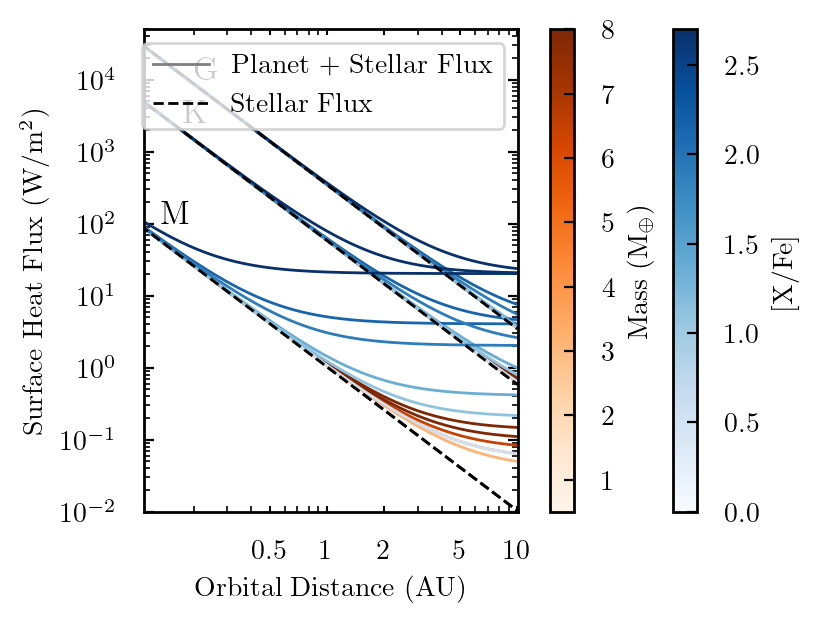

In [661]:
### Plot both X/Fe and M on the same single plot

fig, (ax1) = plt.subplots(1,1, figsize=(4, 3), dpi=200, constrained_layout=True, sharey=True, sharex=True)
# for each of the data points in this scatter plot, we will have a range of distances for each stellar type.
#full_surf_heat_fluxes = []
#conc_1_mass = []
ax1.set_yscale('log')
ax1.set_xlabel('Orbital Distance (AU)')
ax1.set_ylabel(r'Surface Heat Flux (W/m$^2$)')

ax1.set_xscale('log');

# make tick labels for the x-axis 0.5, 1, 2, 5, 10 AU
# but make them integers, not floats
ax1.set_xticks([0.5, 1, 2, 5, 10])
ax1.set_xticklabels(['0.5', '1', '2', '5', '10']);
# but make their tick markers smaller
ax1.tick_params(axis='x', which='major', length=2, width=0.75)

# make a colormap for the concentrations
norm = plt.Normalize(
    vmin=np.log10(concentrations[concentrations > 0]).min(),
    vmax=np.log10(concentrations[concentrations > 0]).max()
)

cmap = plt.cm.Oranges
dist_range = np.arange(100, len(distances), 10) # take every nth distance starting from index m

ref_time = 4.5 #Gyr

full_surf_heat_fluxes = []
mass_1_conc = []

for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux, in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
    if concentration != 1.0:
        continue
    if mass not in [0.5, 1.0, 2.0, 4.0, 8.0]:
        continue
    else:
    #find the index of the time closest to ref_time
        idx = (np.abs(time - ref_time)).argmin()
        full_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
        full_surf_heat_fluxes.append(full_surf_heat_flux)
        mass_1_conc.append((mass))
    
    mass_color = cmap(norm((mass))) 

    distances_for_plot = []
    sum_g_fluxes_for_plot = []
    sum_k_fluxes_for_plot = []
    sum_m_fluxes_for_plot = []

    for dist in distances[dist_range]:
        #print(f"Distance: {dist} AU")
        G2V_stellar_flux = G2V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
        K5V_stellar_flux = K5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
        M5V_stellar_flux = M5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]

        distances_for_plot.append(dist)

        sum_g_flux = full_surf_heat_flux + G2V_stellar_flux / 4
        sum_k_flux = full_surf_heat_flux + K5V_stellar_flux / 4
        sum_m_flux = full_surf_heat_flux + M5V_stellar_flux / 4

        sum_g_fluxes_for_plot.append(sum_g_flux)
        sum_k_fluxes_for_plot.append(sum_k_flux)
        sum_m_fluxes_for_plot.append(sum_m_flux)

        #ax1.scatter(dist, sum_g_flux, c=conc_color, s=5)
        #ax2.scatter(dist, sum_k_flux, c=conc_color, s=5)
        #ax3.scatter(dist, sum_m_flux, c=conc_color, s=5)

    # can we smooth the curves 

    ax1.plot(distances_for_plot, sum_g_fluxes_for_plot, c=mass_color, ls='-', lw=1.0, alpha=1.0)
    ax1.plot(distances_for_plot, sum_k_fluxes_for_plot, c=mass_color, ls='-', lw=1.0, alpha=1.0)
    ax1.plot(distances_for_plot, sum_m_fluxes_for_plot, c=mass_color, ls='-', lw=1.0, alpha=1.0)

ax1.plot(distances,G2V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)
ax1.plot(distances,K5V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)
ax1.plot(distances,M5V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)

# make a colormap for the concentrations
norm = plt.Normalize(
    vmin=np.log10(concentrations[concentrations > 0]).min(),
    vmax=np.log10(concentrations[concentrations > 0]).max()
)

cmap = plt.cm.Blues
dist_range = np.arange(100, len(distances), 10) # take every nth distance starting from index m

ref_time = 4.5 #Gyr

full_surf_heat_fluxes = []
conc_1_mass = []

for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux, in zip(masses, concentrations, times, conv_heat_fluxes, mag_heat_fluxes, surf_heat_fluxes):
    if mass != 1.0: # only plot the files with concentration not equal to 1.0
        continue
    if concentration == 0.0:
        continue
    if concentration not in [0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]: # only plot the files with concentration in this list
        continue
    else:
    #find the index of the time closest to ref_time
        idx = (np.abs(time - ref_time)).argmin()
        full_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
        full_surf_heat_fluxes.append(full_surf_heat_flux)
        conc_1_mass.append(np.log10(concentration))

    conc_color = cmap(norm(np.log10(concentration)))

    distances_for_plot = []
    sum_g_fluxes_for_plot = []
    sum_k_fluxes_for_plot = []
    sum_m_fluxes_for_plot = []

    for dist in distances[dist_range]:
        #print(f"Distance: {dist} AU")
        G2V_stellar_flux = G2V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
        K5V_stellar_flux = K5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]
        M5V_stellar_flux = M5V_stellar_fluxes_log_interp_values[np.argmin(np.abs(distances - dist))]

        distances_for_plot.append(dist)

        sum_g_flux = full_surf_heat_flux + G2V_stellar_flux / 4
        sum_k_flux = full_surf_heat_flux + K5V_stellar_flux / 4 
        sum_m_flux = full_surf_heat_flux + M5V_stellar_flux / 4

        sum_g_fluxes_for_plot.append(sum_g_flux)
        sum_k_fluxes_for_plot.append(sum_k_flux)
        sum_m_fluxes_for_plot.append(sum_m_flux)

        #ax1.scatter(dist, sum_g_flux, c=conc_color, s=5)
        #ax2.scatter(dist, sum_k_flux, c=conc_color, s=5)
        #ax3.scatter(dist, sum_m_flux, c=conc_color, s=5)

    # can we smooth the curves 
    ax1.plot(distances_for_plot, sum_g_fluxes_for_plot, c=conc_color, ls='-', lw=1.0, alpha=1.0)
    ax1.plot(distances_for_plot, sum_k_fluxes_for_plot, c=conc_color, ls='-', lw=1.0, alpha=1.0)
    ax1.plot(distances_for_plot, sum_m_fluxes_for_plot, c=conc_color, ls='-', lw=1.0, alpha=1.0)

ax1.plot(distances,G2V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)
ax1.plot(distances,K5V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)
ax1.plot(distances,M5V_stellar_fluxes_log_interp_values/4, c='black', ls='--', lw=1.0)

# make fake data points for the sum lines
ax1.plot([],[],label='Planet + Stellar Flux', ls='-', lw=1, c='Grey')
ax1.plot([],[],label='Stellar Flux', ls='--', lw=1, c='k')
ax1.legend(loc='upper right',fontsize=10)

# add a colorbar for the concentrations
# but make the colorbar reflect the trimmed colormap Greys 0.25 to 1.0.
sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=min(conc_1_mass), vmax=max(conc_1_mass)))
cb = plt.colorbar(sm, ax=ax1, label='[X/Fe]')

# add a colorbar for the concentrations
# but make the colorbar reflect the trimmed colormap Greys 0.25 to 1.0.
sm = plt.cm.ScalarMappable(cmap='Oranges', norm=plt.Normalize(vmin=min(mass_1_conc), vmax=max(mass_1_conc)))
cb = plt.colorbar(sm, ax=ax1, label=r'Mass ($\rm{M_{\oplus}}$)')

ax1.set_xlim(min(distances_for_plot), max(distances_for_plot)+0.1);
ax1.set_ylim(1e-2,5e4)

# add text labels for each plot:
# G, K, M stars / (a) (b) (c)
ax1.text(s='G',x=0.20, y=1e4, fontsize=12)
ax1.text(s='K',x=0.175, y=2.5e3, fontsize=12)
ax1.text(s='M',x=0.135, y=1e2, fontsize=12);

# add information about the Urey Ratio

### we should be computing this value as well - important for the thermal evolution of the planet, and knowing
### the difference in Urey ratio as a function of concentration and mass will be helpful in our analysis

In [639]:
list_files = !ls {radiogenic_mass_sweep_dir}*heat_production*.dat

#masses = []
#concentrations = []
#times = []
qs_crust = []; qs_mantle = []; Q_totals = []

for file in list_files:
    #mass = float(file.split('_')[-3].split('m')[0])
    #concentration = float(file.split('_')[-2])
    #masses.append(mass)
    #concentrations.append(concentration)
    # read the files
    time, q_crust, q_mantle = np.genfromtxt(file, unpack=True)
    # append data to lists
    #times.append(time)
    qs_crust.append(q_crust)
    qs_mantle.append(q_mantle)
    Q_totals.append(q_crust + q_mantle)
    print(len(time), len(q_crust))

#times = np.array(times); conv_heat_fluxes = np.array(conv_heat_fluxes); mag_heat_fluxes = np.array(mag_heat_fluxes); surf_heat_fluxes = np.array(surf_heat_fluxes)
#masses = np.array(masses); concentrations = np.array(concentrations)
#unique_masses = np.unique(masses); unique_concentrations = np.unique(concentrations)

#print(f"Unique masses: {unique_masses}")
#print(f"Unique concentrations: {unique_concentrations}")

1603 1603
1369 1369
1392 1392
1411 1411
1437 1437
1452 1452
1485 1485
1537 1537
3692 3692
26535 26535
29269 29269
33393 33393
5566 5566
34890 34890
36886 36886
2204 2204
7226 7226
40103 40103
2318 2318
9238 9238
47211 47211
2493 2493
11542 11542
51245 51245
2653 2653
14700 14700
55300 55300
2835 2835
17256 17256
3042 3042
20761 20761
3277 3277
21297 21297
3594 3594
23798 23798
856 856
1296 1296
1318 1318
1335 1335
1353 1353
1457 1457
2012 2012
2077 2077
4338 4338
30294 30294
34509 34509
37010 37010
6287 6287
38463 38463
42015 42015
2114 2114
8165 8165
43979 43979
2378 2378
11259 11259
49778 49778
2575 2575
14379 14379
55069 55069
2834 2834
17061 17061
58499 58499
3076 3076
20164 20164
3478 3478
22741 22741
3626 3626
25940 25940
3558 3558
27525 27525
779 779
1243 1243
1264 1264
1256 1256
1373 1373
1904 1904
1970 1970
1957 1957
7685 7685
44148 44148
47448 47448
50404 50404
10960 10960
51583 51583
53780 53780
2264 2264
12635 12635
56030 56030
2958 2958
19517 19517
65597 65597
2624 2624
25

In [623]:
len(times), len(qs_crust)

(1540, 491)

In [638]:
len(qs_mantle[480]), len(Q_totals[480]), len(times[480]), len(surf_heat_fluxes[480])

(4336, 4336, 50853, 50853)

### time arrays should be exactly the same
### new data is the Urey ratio, which we compute here

In [572]:
# total heat production 
#Q_crust = qs_crust
#Q_mantle = qs_mantle

#Q_total = qs_crust + qs_mantle
#Q_surf_loss = (mag_heat_fluxes + surf_heat_fluxes) * ( 4 * np.pi * R_planet**2 )

In [573]:
def compute_radius_from_scaling_law(mass):
    """
    input:  mass in earth masses
    output: radius in earth radii
    """
    return R_Earth * mass ** 0.27

0.1 1452
0.2 1457
0.3 1904
0.4 1861
0.5 1833
0.6 1858
0.7 1856
0.8 1892
0.9 1867
1.0 57744


ValueError: operands could not be broadcast together with shapes (57744,) (1884,) 

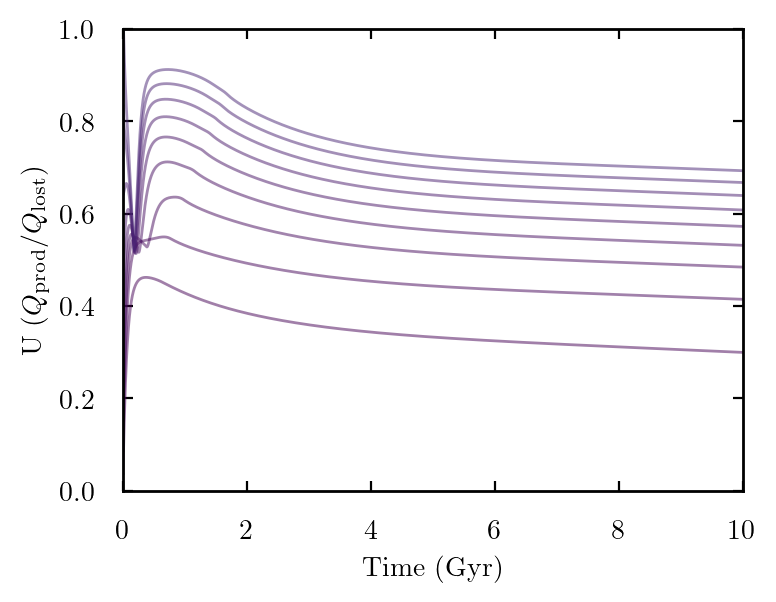

In [603]:
# to compute the Urey ratio, we need to loop through the masses and concentrations.
radii = []
Urey_ratios = []

current_len = len(qs_crust)

fig, ax = plt.subplots(1,1,figsize=(4,3),dpi=200)
ax.set_ylim(0,1)
ax.set_xlim(0,10)
ax.set_xlabel('Time (Gyr)')
ax.set_ylabel(r'U ($Q_\mathrm{prod} / Q_\mathrm{lost}$)')

for mass, concentration, time, mag_heat_flux, conv_heat_flux, surf_heat_flux, q_crust, q_mantle, Q_total in zip(masses[:current_len], concentrations[:current_len], times[:current_len], mag_heat_fluxes[:current_len], conv_heat_fluxes[:current_len], surf_heat_fluxes[:current_len], qs_crust[:current_len], qs_mantle[:current_len], Q_totals[:current_len]):
    # keep concentration constant here
    if concentration != 1.0:
        continue
    print(mass,len(Q_total))
    # from the mass, compute the radius, because we need the surface area
    radius = compute_radius_from_scaling_law(mass)
    radii.append(radius)
    # compute Urey ratio: Q_prod / Q_lost
    # Q_prod is the total heat production from radiogenic sources, and Q_lost is the heat flux out times the surface area of the planet. (this is also a function of time!)
    Urey_ratio = (Q_total) / (( mag_heat_flux + surf_heat_flux ) * 4 * np.pi * (radius*R_Earth))
    ax.plot(time, Urey_ratio, alpha=0.5, lw=1, c=plt.cm.viridis((mass - min(masses)) / (max(masses) - min(masses))))

plt.colorbar(plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(masses), vmax=max(masses))), ax=ax, label='Planet Mass (M$_\oplus$)')

0.1
0.5370317963702527
0.02160483
1120
4.500889
2003046000000.0
0.3377128278312161

0.2
0.6475571437820812
0.02730968
1125
4.498005
4050162200000.0
0.44800740631514346

0.3
0.7224748587578399
0.03179391
1572
4.499834
6109961000000.0
0.5203304557761257

0.4
0.7808294728495048
0.03593639
1530
4.504679
8173889000000.0
0.5698303518309696

0.5
0.8293195458144417
0.03962372
1501
4.494676
10271529000000.0
0.6114563185395682



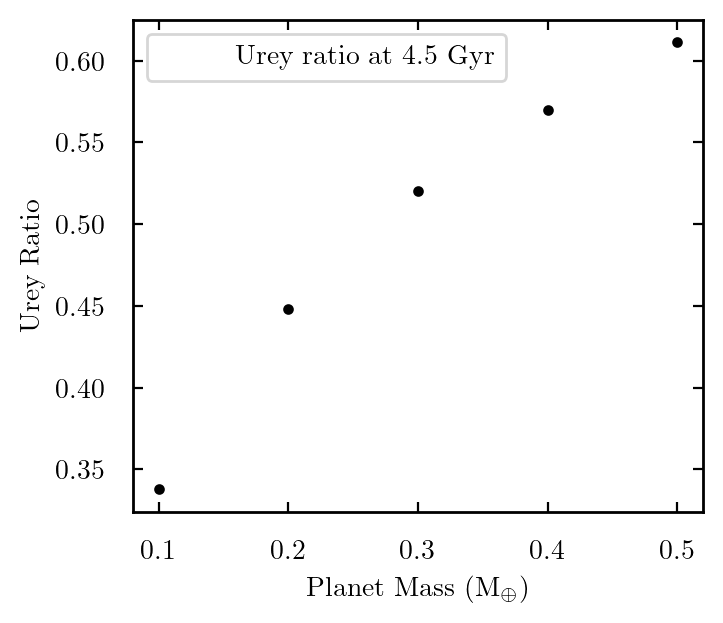

In [592]:
# for a given time, how does the total surface heat flux vary with planet mass? Use 4.5 Gyr as reference time
ref_time = 4.5 #Gyr

fig, ax = plt.subplots(1,1, figsize=(3.5, 3), dpi=200, constrained_layout=True)
ax.set_xlabel('Planet Mass (M$_\oplus$)')
ax.set_ylabel('Urey Ratio')
ax.set_xscale('linear')

current_len = len(qs_crust)

for mass, concentration, time, conv_heat_flux, mag_heat_flux, surf_heat_flux, Q_total in zip(masses[:current_len], concentrations[:current_len], times[:current_len], conv_heat_fluxes[:current_len], mag_heat_fluxes[:current_len], surf_heat_fluxes[:current_len], Q_totals[:current_len]):
    if concentration != 1.0: # only plot the files with concentration not equal to 1.0
        continue

    if mass not in [0.1, 0.2, 0.3, 0.4, 0.5]: #, 1.0, 2.0, 4.0, 8.0]:
        continue
    else:
        radius = compute_radius_from_scaling_law(mass)
        print(mass)
        print(radius / R_Earth)
        
        # find the index of the time closest to ref_time
        idx = np.argmin(np.abs(time - ref_time))
        total_surf_heat_flux = surf_heat_flux[idx] + mag_heat_flux[idx]
        print(total_surf_heat_flux)
        print(idx)
        print(time[idx])
        print(Q_total[idx])
        Urey_ratio = (Q_total[idx]) / (( total_surf_heat_flux ) * 4 * np.pi * (radius*R_Earth))
        print(Urey_ratio)
        print()
        ax.scatter(mass, Urey_ratio, c='black', s=8)

# add dummy points for the legend
ax.scatter([], [], c='black', s=0, label=fr'Urey ratio at {ref_time:3.1f} Gyr')
ax.legend(fontsize=10)

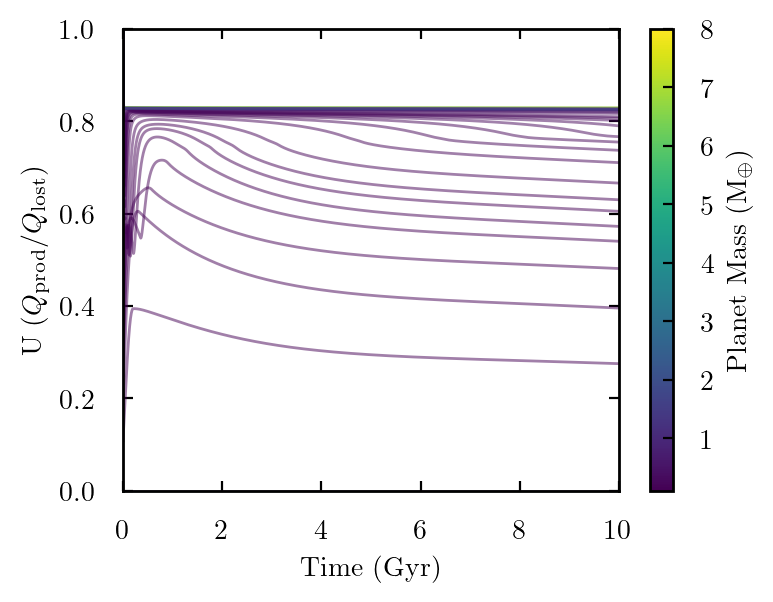

In [593]:
# to compute the Urey ratio, we need to loop through the masses and concentrations.
radii = []
Urey_ratios = []

current_len = len(qs_crust)

fig, ax = plt.subplots(1,1,figsize=(4,3),dpi=200)
ax.set_ylim(0,1)
ax.set_xlim(0,10)
ax.set_xlabel('Time (Gyr)')
ax.set_ylabel(r'U ($Q_\mathrm{prod} / Q_\mathrm{lost}$)')

for mass, concentration, time, mag_heat_flux, conv_heat_flux, surf_heat_flux, q_crust, q_mantle, Q_total in zip(masses[:current_len], concentrations[:current_len], times[:current_len], mag_heat_fluxes[:current_len], conv_heat_fluxes[:current_len], surf_heat_fluxes[:current_len], qs_crust[:current_len], qs_mantle[:current_len], Q_totals[:current_len]):
    # keep concentration constant here
    if mass != 0.5:
        continue

    # from the mass, compute the radius, because we need the surface area
    radius = compute_radius_from_scaling_law(mass)
    radii.append(radius)
    # compute Urey ratio: Q_prod / Q_lost
    # Q_prod is the total heat production from radiogenic sources, and Q_lost is the heat flux out times the surface area of the planet. (this is also a function of time!)
    Urey_ratio = (Q_total) / (( mag_heat_flux + surf_heat_flux ) * 4 * np.pi * (radius*R_Earth))
    ax.plot(time, Urey_ratio, alpha=0.5, lw=1, c=plt.cm.viridis((concentration - min(concentrations)) / (max(concentrations) - min(concentrations))))
plt.colorbar(plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(masses), vmax=max(masses))), ax=ax, label='Planet Mass (M$_\oplus$)')